# Quartz-only Torquato descriptors across the KMZ deformation gradient

Tests whether the standard n-point statistical descriptors (S₂, lineal
path L, pore-size F, chord length, cluster C₂) discriminate the three
Kuckaus mylonite samples at increasing strain.

**Key diagnostic**: the **C₂/S₂ ratio** — where C₂(r) is the two-point
cluster function (probability both ends of a vector *r* lie in the
same connected quartz cluster) and S₂(r) is the standard two-point
correlation (probability both ends lie in quartz at all). The ratio
tells you how much of the quartz phase is connected at scale *r*:

- **C₂/S₂ → 1 at all r**: quartz forms a single connected framework
  (expected for Protomylonite / Mylonite where ribbons stay intact)
- **C₂/S₂ drops at large r**: quartz is fragmented into disconnected
  islands — you can find pairs in the phase but they're in different
  clusters (expected for Ultramylonite if the matrix has broken up
  the quartz ribbons)

**Porespy** handles S₂, L, F, chord; the cluster functions are custom
because neither porespy nor npcfs.jl exposes a cluster-restricted
n-point. The anisotropic (r, θ) versions are custom FFT + angular
binning on top of porespy's binary-mask machinery.

*Kernel*: `xsmurf` (has porespy, numpy 2.4, scipy 1.17, scikit-image
0.26, numba 0.64, mlx).

In [32]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import porespy as ps
from pathlib import Path
from scipy.fft import fft2, ifft2
from scipy.ndimage import label
print('porespy', ps.__version__, ' numpy', np.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
porespy 3.0.4  numpy 2.4.3


## EBSD reader

Copied inline so the notebook is self-contained in the xsmurf env
(doesn't require recurrence2d to be importable here).

In [33]:
import re as _re
import pandas as pd

# --- CPR/CRC binary reader (Oxford Instruments Channel 5 format) ---
_CPR_FIELDS = {
    3: ('ph1', 'float32'), 4: ('phi', 'float32'), 5: ('ph2', 'float32'),
    6: ('MAD', 'float32'), 7: ('BC', 'uint8'), 8: ('BS', 'uint8'),
    10: ('numBands', 'uint8'), 11: ('AFI', 'uint8'), 12: ('IB6', 'float32'),
}

def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}; current = None
    group_re = _re.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'): continue
        m = group_re.match(line)
        if m:
            current = m.group(1); groups.setdefault(current, {}); continue
        if current is None: continue
        if '=' in line:
            k, v = line.split('=', 1); groups[current][k.strip()] = v.strip()
    return groups

def read_cpr(filepath):
    filepath = Path(filepath)
    cpr = filepath.with_suffix('.cpr'); crc = filepath.with_suffix('.crc')
    g = _parse_cpr_ini(cpr)
    job = g.get('Job', {})
    nx, ny = int(job['xCells']), int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))
    pg = g.get('Phases', {}); n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = g.get(f'Phase{i}', {})
        phases[i] = [f"{pi.get('a','?')};{pi.get('b','?')};{pi.get('c','?')}",
                     f"{pi.get('alpha','?')};{pi.get('beta','?')};{pi.get('gamma','?')}",
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]
    fg = g.get('Fields', {}); n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]
    for i in range(1, n_fields + 1):
        cd = int(fg[f'Field{i}'])
        dtype_items.append(_CPR_FIELDS.get(cd, (f'unknown_{cd}', 'float32')))
    raw = np.fromfile(str(crc), dtype=np.dtype(dtype_items), count=nx*ny)
    if raw.size != nx*ny: raw = raw[:nx*ny]
    shape = (ny, nx)
    data = {'meta': {'name': filepath.stem, 'xcells': nx, 'ycells': ny,
                      'xstep': xstep, 'ystep': ystep,
                      'phases': phases, 'n_phases': n_phases},
            'phase': raw['phase'].reshape(shape)}
    for src, dst in [('ph1','euler1'), ('phi','euler2'), ('ph2','euler3')]:
        if src in raw.dtype.names:
            data[dst] = np.rad2deg(raw[src].reshape(shape)).astype(np.float32)
    for src, dst in [('MAD','mad'), ('BC','bc'), ('BS','bs')]:
        if src in raw.dtype.names:
            data[dst] = raw[src].reshape(shape)
    return data


# --- CTF (Channel Text File) reader ---
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf ASCII file. Returns the same dict shape
    as read_cpr() so downstream code is reader-agnostic."""
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()
    meta = {'name': filepath.stem}
    phases = {}
    header_line = None
    for i, line in enumerate(lines):
        s = line.strip()
        if s.startswith('XCells'):       meta['xcells'] = int(s.split('\t')[1])
        elif s.startswith('YCells'):     meta['ycells'] = int(s.split('\t')[1])
        elif s.startswith('XStep'):      meta['xstep']  = float(s.split('\t')[1])
        elif s.startswith('YStep'):      meta['ystep']  = float(s.split('\t')[1])
        elif s.startswith('Phases'):
            nph = int(s.split('\t')[1])
            for j in range(1, nph + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = nph
        elif s.startswith('Phase\tX\tY'):
            header_line = i; break
    if header_line is None:
        raise ValueError(f'No data header in {filepath}')
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line,
                      engine='python', on_bad_lines='skip')
    nx, ny = meta['xcells'], meta['ycells']
    if len(df) > nx * ny:
        df = df.iloc[:nx * ny]
    data = {'meta': meta, 'phase': df['Phase'].values.reshape(ny, nx).astype('uint8')}
    if 'Euler1' in df: data['euler1'] = df['Euler1'].values.reshape(ny, nx).astype('float32')
    if 'Euler2' in df: data['euler2'] = df['Euler2'].values.reshape(ny, nx).astype('float32')
    if 'Euler3' in df: data['euler3'] = df['Euler3'].values.reshape(ny, nx).astype('float32')
    if 'MAD'    in df: data['mad']    = df['MAD'].values.reshape(ny, nx).astype('float32')
    if 'BC'     in df: data['bc']     = df['BC'].values.reshape(ny, nx)
    if 'BS'     in df: data['bs']     = df['BS'].values.reshape(ny, nx)
    return data


# --- Dispatcher: read any EBSD file by extension ---
def read_ebsd(filepath):
    """Dispatch to read_cpr / read_ctf based on file extension."""
    p = Path(filepath)
    suffix = p.suffix.lower()
    if suffix == '.cpr': return read_cpr(p)
    if suffix == '.ctf': return read_ctf(p)
    raise ValueError(f'Unrecognized EBSD extension {suffix!r} (expected .cpr or .ctf)')

## Stitch splitting

The Protomylonite and Mylonite maps are two adjacent acquisitions
stitched together; the seam shows up as a near-100%-unindexed column
that would corrupt S₂, L, C₂, everything. The Ultramylonite is a single
acquisition so it passes through unchanged.

`split_stitched` detects the seam + trims the low-indexing strip at
the top and bottom of each map, and returns one dict per clean tile.

In [34]:
def split_stitched(ebsd, col_frac_thr=0.4, row_frac_thr=0.4,
                    buffer_px=3, min_side_px=64):
    # Return list of sub-ebsd dicts, one per tile (split on interior
    # stitch columns, top/bottom trimmed of unindexed strips).
    pm = ebsd['phase']
    ny, nx = pm.shape
    col_un = (pm == 0).mean(axis=0)
    row_un = (pm == 0).mean(axis=1)
    bad_c = col_un > max(col_frac_thr, 3 * np.median(col_un))
    bad_r = row_un > max(row_frac_thr, 3 * np.median(row_un))

    # Interior stitch runs
    cuts = []
    i = 0
    while i < nx:
        if bad_c[i]:
            j = i
            while j < nx and bad_c[j]:
                j += 1
            if i > buffer_px and j < nx - buffer_px:
                cuts.append((i, j))
            i = j
        else:
            i += 1

    if cuts:
        col_ranges, prev = [], 0
        for (a, b) in cuts:
            col_ranges.append((prev, a))
            prev = b
        col_ranges.append((prev, nx))
    else:
        col_ranges = [(0, nx)]

    # Top/bottom row trim
    top = 0
    while top < ny and bad_r[top]: top += 1
    bot = ny
    while bot > 0 and bad_r[bot - 1]: bot -= 1
    if bot - top < 0.5 * ny:
        top, bot = 0, ny

    tiles = []
    for ti, (c0, c1) in enumerate(col_ranges):
        if ti > 0: c0 += buffer_px
        if ti < len(col_ranges) - 1: c1 -= buffer_px
        if (c1 - c0) < min_side_px or (bot - top) < min_side_px:
            continue
        sub = {k: (v[top:bot, c0:c1].copy() if hasattr(v, 'shape') and v.ndim == 2 else v)
                for k, v in ebsd.items() if k != 'meta'}
        meta = dict(ebsd['meta'])
        meta['xcells'] = c1 - c0
        meta['ycells'] = bot - top
        meta['name'] = f"{ebsd['meta'].get('name', 'ebsd')}_tile{ti + 1}"
        meta['crop'] = {'rows': (top, bot), 'cols': (c0, c1)}
        sub['meta'] = meta
        tiles.append(sub)
    return tiles

In [35]:
# ===== Dataset selection: pick from any EBSD file in EBSD/ =====
# Lists all .ctf / .cpr files (real or inside zip archives), prints them
# with indices, and loads the ones you select. Replaces the hardcoded
# Kuckaus-only loader so you can analyze any dataset in EBSD/.

import sys
sys.path.insert(0, str(Path('.').resolve()))
from wtmm.ebsd_zip import list_ebsd_files, ZipEntry, open_ebsd

EBSD_DIR = Path('EBSD')
all_files = list_ebsd_files(EBSD_DIR)

# ---- USER PARAMETERS ----
# Which file indices (from the listing below) to load. Empty list = print
# the listing and stop.
SELECTED_INDICES = [79]           # e.g. [12, 13, 14] for 3-sample comparison

# Per-sample 90-degree rotations to bring all maps into a common
# (x = lineation, y = foliation-normal) frame. Key by either INDEX (int)
# or sample name (str = path stem). Negative k = clockwise.
SAMPLE_ROTATIONS = {}           # e.g. {'Ultramylonite': -1}

# MAD cleanup threshold (degrees) for the quartz mask. Set None to disable.
# 1.5° is the standard Hough-EBSD quartz cutoff (catches phase-forced
# non-quartz pixels in single-phase scans).
MAD_CUTOFF_DEG = 1.5

# Whether to apply split_stitched. Stitched scans (Aztec "Stitch of N
# projects") have seam columns of unindexed pixels that corrupt n-point
# statistics. For non-stitched scans this is a no-op.
DO_SPLIT_STITCHED = True
# -------------------------

# Print the listing
print(f'Found {len(all_files)} EBSD files in {EBSD_DIR}/:\n')
for i, p in enumerate(all_files):
    rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
    kind = '[zip]' if isinstance(p, ZipEntry) else '     '
    print(f'  [{i:3d}] {kind} {rel}')

if not SELECTED_INDICES:
    print()
    print('SELECTED_INDICES is empty.  Pick file indices above and re-run.')
    print()
    print('Examples:')
    print('  # Original Kuckaus mylonite analysis (find indices in listing):')
    print("  SELECTED_INDICES = [<find Protomylonite>, <Mylonite>, <Ultramylonite>]")
    print("  SAMPLE_ROTATIONS = {'Ultramylonite': -1}")
    print()
    print('  # Single-sample analysis:')
    print('  SELECTED_INDICES = [42]')
    samples = {}
else:
    samples = {}
    for idx in SELECTED_INDICES:
        if not (0 <= idx < len(all_files)):
            print(f'  ERROR: index {idx} out of range [0, {len(all_files)})')
            continue
        p = all_files[idx]
        rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
        # Sample name: stem of the file (handles ZipEntry too)
        sample_name = (Path(p.entry).stem if isinstance(p, ZipEntry)
                        else Path(str(p)).stem)
        # open_ebsd: yields a real path for both real files and zip entries
        with open_ebsd(p) as real_path:
            e_full = read_ebsd(real_path)
        e_full['meta']['name'] = sample_name
        e_full['meta']['source_path'] = str(rel)
        e_full['meta']['source_idx']  = int(idx)

        # Resolve rotation: dict key may be int(idx) or str(name)
        k = SAMPLE_ROTATIONS.get(idx, SAMPLE_ROTATIONS.get(sample_name, 0))

        # Split stitched scans (no-op for single-tile scans)
        tiles = (split_stitched(e_full) if DO_SPLIT_STITCHED else [e_full])
        if len(tiles) == 1:
            tiles[0]['meta']['name'] = sample_name

        for ti, e in enumerate(tiles):
            # Apply per-sample rotation
            if k:
                for key, v in list(e.items()):
                    if key == 'meta': continue
                    if hasattr(v, 'shape') and v.ndim == 2:
                        e[key] = np.rot90(v, k=k).copy()
                m = e['meta']
                m['xcells'], m['ycells'] = m['ycells'], m['xcells']
                m['xstep'],  m['ystep']  = m['ystep'],  m['xstep']
                m['rotated_k'] = k

            m = e['meta']
            pnames = {pid: info[2] for pid, info in m['phases'].items()}
            qid = next((pid for pid, n in pnames.items() if 'quartz' in n.lower()),
                        None)
            if qid is None:
                # No quartz declared in this file -- skip it for the npcf analysis,
                # OR fall back to phase 1 with a warning if user really wants to.
                print(f'  WARN: {m["name"]}: no phase named "quartz" -- skipping')
                continue

            qm_raw = (e['phase'] == qid)
            if MAD_CUTOFF_DEG is not None and 'mad' in e and e['mad'] is not None:
                mad_ok = e['mad'] < MAD_CUTOFF_DEG
                qm = qm_raw & mad_ok
                n_drop = int(qm_raw.sum() - qm.sum())
                frac_drop = (100 * n_drop / max(int(qm_raw.sum()), 1)
                              if qm_raw.any() else 0.0)
            else:
                qm = qm_raw
                n_drop = 0
                frac_drop = 0.0

            # Tag (handle multi-tile scans by appending tile index)
            tag = m['name'] if len(tiles) == 1 else f'{m["name"]}_t{ti}'
            samples[tag] = {'ebsd': e, 'quartz_id': qid,
                             'quartz_mask': qm,
                             'quartz_mask_raw': qm_raw,
                             'phi_quartz':       float(qm.mean()),
                             'phi_quartz_raw':   float(qm_raw.mean()),
                             'mad_cutoff_deg':   MAD_CUTOFF_DEG,
                             'n_dropped_by_mad': n_drop,
                             'source_idx':       int(idx),
                             'source_path':      str(rel),
                             'tile_index':       ti}
            rot_tag = f'  rot={k*90}°' if k else ''
            mad_tag = (f'  MAD-drop={frac_drop:.1f}%'
                        if MAD_CUTOFF_DEG is not None else '')
            print(f'{tag:<30s} {m["xcells"]}x{m["ycells"]} @ {m["xstep"]:.2f} um  '
                  f'phi(Qtz)={qm.mean():.3f}{rot_tag}{mad_tag}')

    print(f'\nLoaded {len(samples)} sample tile(s).')


Found 94 EBSD files in EBSD/:

  [  0]       2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Processed.ctf
  [  1]       2013-05-16_Pearce_Mark_6535v1/data/Overview_Map_Raw.ctf
  [  2]       2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Processed.ctf
  [  3]       2013-05-16_Pearce_Mark_6535v1/data/Siderite_Detail_Raw.ctf
  [  4]       2015-06-19_Pearce_Mark_13960v1/data/Large_Albite.ctf
  [  5]       2015-06-19_Pearce_Mark_13960v1/data/Large_Albite_processed.ctf
  [  6]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_Original.ctf
  [  7]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ci.ctf
  [  8]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4cii.ctf
  [  9]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4ciii.ctf
  [ 10]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4di.ctf
  [ 11]       2015-06-26_Pearce_Mark_13963v1/data/Twinned_Plag_processed_Fig4dii.ctf
  [ 12]       2015-06-26_Pe

### Interactive dataset picker

Click files in the multi-select to choose them. **Inspect zip** shows the full content of the parent archive for any zip entry you click. **Peek metadata** prints phases declared, step size, magnification, etc. for the selected files. **Load selected** actually loads them and populates `samples`.

If you don't want widgets, ignore this cell and use cell 6's `SELECTED_INDICES = [...]` fallback.

In [ ]:
# ===== Interactive dataset picker =====
import zipfile
import ipywidgets as widgets
from IPython.display import display, clear_output

# Build descriptive labels
def _file_label(p):
    rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
    kind = '[zip]' if isinstance(p, ZipEntry) else '     '
    return f'{kind} {rel}'

_dataset_select = widgets.SelectMultiple(
    options=[(f'[{i:3d}]  {_file_label(p)}', i) for i, p in enumerate(all_files)],
    rows=20, description='Files:',
    layout=widgets.Layout(width='95%'),
    style={'description_width': '60px'})

_mad_w = widgets.FloatText(value=1.5, description='MAD cutoff (deg):',
    layout=widgets.Layout(width='220px'),
    style={'description_width': '120px'})
_split_w = widgets.Checkbox(value=True, description='split_stitched',
    layout=widgets.Layout(width='150px'))
_rot_w = widgets.Text(value='', description='Rotations:',
    placeholder='e.g. {"Ultramylonite": -1, 5: 1}',
    layout=widgets.Layout(width='95%'),
    style={'description_width': '80px'})

_btn_peek_meta = widgets.Button(description='Peek metadata',
    layout=widgets.Layout(width='150px'))
_btn_peek_zip  = widgets.Button(description='Inspect zip',
    layout=widgets.Layout(width='150px'))
_btn_load      = widgets.Button(description='Load selected',
    button_style='success', layout=widgets.Layout(width='150px'))
_out = widgets.Output(layout=widgets.Layout(border='1px solid #ccc',
                                              max_height='400px',
                                              overflow='auto'))

def _on_peek_meta(_=None):
    with _out:
        clear_output(); idxs = list(_dataset_select.value)
        if not idxs:
            print('No files selected'); return
        for idx in idxs:
            p = all_files[idx]
            try:
                with open_ebsd(p) as real_path:
                    e = read_ebsd(real_path)
                m = e['meta']
                print(f'[{idx:3d}] {_file_label(p)}')
                print(f'      grid: {m["xcells"]}x{m["ycells"]} @ '
                      f'{m["xstep"]:.3f}x{m["ystep"]:.3f} um')
                print(f'      n_phases: {m["n_phases"]}')
                for pid, info in m['phases'].items():
                    print(f'        phase {pid}: {info[2]} (Laue {info[3] if len(info)>3 else "?"})')
                # Phase composition
                p_arr = e['phase']
                tot = p_arr.size
                comp = ', '.join(
                    f'{pid}={100*(p_arr==pid).sum()/tot:.1f}%'
                    for pid in [0] + list(m['phases'].keys()))
                print(f'      composition: {comp}')
                print()
            except Exception as exc:
                print(f'  ERROR reading {p}: {exc}\n')

def _on_peek_zip(_=None):
    with _out:
        clear_output(); idxs = list(_dataset_select.value)
        if not idxs:
            print('No files selected'); return
        zips_seen = set()
        for idx in idxs:
            p = all_files[idx]
            if not isinstance(p, ZipEntry):
                print(f'[{idx:3d}] not a zip entry: {_file_label(p)}\n'); continue
            zp = p.zip_path
            if zp in zips_seen: continue
            zips_seen.add(zp)
            print(f'=== {zp.name} ===')
            try:
                with zipfile.ZipFile(zp) as zf:
                    for info in zf.infolist():
                        if info.is_dir(): continue
                        sz_mb = info.file_size / 1024 / 1024
                        marker = ' *' if Path(info.filename).suffix.lower() in ('.cpr', '.ctf') else ''
                        print(f'  {sz_mb:8.2f} MB   {info.filename}{marker}')
            except Exception as exc:
                print(f'  ERROR opening {zp}: {exc}')
            print()

def _on_load(_=None):
    global samples, SELECTED_INDICES, SAMPLE_ROTATIONS, MAD_CUTOFF_DEG, DO_SPLIT_STITCHED
    with _out:
        clear_output()
        SELECTED_INDICES = list(_dataset_select.value)
        # Parse rotations dict
        rot_text = _rot_w.value.strip()
        if rot_text:
            try:
                SAMPLE_ROTATIONS = eval(rot_text, {'__builtins__': {}}, {})
                if not isinstance(SAMPLE_ROTATIONS, dict):
                    raise TypeError('rotation spec must be a dict')
            except Exception as exc:
                print(f'  ERROR parsing rotations: {exc}'); return
        else:
            SAMPLE_ROTATIONS = {}
        MAD_CUTOFF_DEG = float(_mad_w.value) if _mad_w.value else None
        DO_SPLIT_STITCHED = bool(_split_w.value)

        if not SELECTED_INDICES:
            print('No files selected'); return
        print(f'Loading {len(SELECTED_INDICES)} file(s)...')
        print(f'  MAD_CUTOFF_DEG = {MAD_CUTOFF_DEG}')
        print(f'  SAMPLE_ROTATIONS = {SAMPLE_ROTATIONS}')
        print(f'  DO_SPLIT_STITCHED = {DO_SPLIT_STITCHED}')
        print()

        samples = {}
        for idx in SELECTED_INDICES:
            p = all_files[idx]
            rel = p.relative_to(EBSD_DIR) if hasattr(p, 'relative_to') else Path(str(p))
            sample_name = (Path(p.entry).stem if isinstance(p, ZipEntry)
                            else Path(str(p)).stem)
            try:
                with open_ebsd(p) as real_path:
                    e_full = read_ebsd(real_path)
            except Exception as exc:
                print(f'  ERROR loading {sample_name}: {exc}'); continue

            e_full['meta']['name'] = sample_name
            e_full['meta']['source_path'] = str(rel)
            e_full['meta']['source_idx']  = int(idx)

            k = SAMPLE_ROTATIONS.get(idx, SAMPLE_ROTATIONS.get(sample_name, 0))
            tiles = (split_stitched(e_full) if DO_SPLIT_STITCHED else [e_full])
            if len(tiles) == 1:
                tiles[0]['meta']['name'] = sample_name

            for ti, e in enumerate(tiles):
                if k:
                    for key, v in list(e.items()):
                        if key == 'meta': continue
                        if hasattr(v, 'shape') and v.ndim == 2:
                            e[key] = np.rot90(v, k=k).copy()
                    m = e['meta']
                    m['xcells'], m['ycells'] = m['ycells'], m['xcells']
                    m['xstep'],  m['ystep']  = m['ystep'],  m['xstep']
                    m['rotated_k'] = k

                m = e['meta']
                pnames = {pid: info[2] for pid, info in m['phases'].items()}
                qid = next((pid for pid, n in pnames.items() if 'quartz' in n.lower()),
                            None)
                if qid is None:
                    print(f'  WARN: {m["name"]}: no quartz phase declared, skipping')
                    continue

                qm_raw = (e['phase'] == qid)
                if MAD_CUTOFF_DEG is not None and 'mad' in e and e['mad'] is not None:
                    qm = qm_raw & (e['mad'] < MAD_CUTOFF_DEG)
                    n_drop = int(qm_raw.sum() - qm.sum())
                    frac_drop = (100*n_drop/max(int(qm_raw.sum()),1) if qm_raw.any() else 0.0)
                else:
                    qm = qm_raw; n_drop = 0; frac_drop = 0.0

                tag = m['name'] if len(tiles) == 1 else f'{m["name"]}_t{ti}'
                samples[tag] = {'ebsd': e, 'quartz_id': qid,
                                 'quartz_mask': qm, 'quartz_mask_raw': qm_raw,
                                 'phi_quartz': float(qm.mean()),
                                 'phi_quartz_raw': float(qm_raw.mean()),
                                 'mad_cutoff_deg': MAD_CUTOFF_DEG,
                                 'n_dropped_by_mad': n_drop,
                                 'source_idx': int(idx),
                                 'source_path': str(rel),
                                 'tile_index': ti}
                rot_tag = f'  rot={k*90}°' if k else ''
                mad_tag = (f'  MAD-drop={frac_drop:.1f}%'
                            if MAD_CUTOFF_DEG is not None else '')
                print(f'{tag:<30s} {m["xcells"]}x{m["ycells"]} @ {m["xstep"]:.2f} um  '
                      f'phi(Qtz)={qm.mean():.3f}{rot_tag}{mad_tag}')

        print(f'\n=> samples dict has {len(samples)} tile(s).  '
               f'Re-run downstream cells (8 onward).')

_btn_peek_meta.on_click(_on_peek_meta)
_btn_peek_zip.on_click(_on_peek_zip)
_btn_load.on_click(_on_load)

display(_dataset_select)
display(widgets.HBox([_mad_w, _split_w]))
display(_rot_w)
display(widgets.HBox([_btn_peek_meta, _btn_peek_zip, _btn_load]))
display(_out)


SelectMultiple(description='Files:', layout=Layout(width='95%'), options=(('[  0]        2013-05-16_Pearce_Mar…

Text(value='', description='Rotations:', layout=Layout(width='95%'), placeholder='e.g. {"Ultramylonite": -1, 5…

Output(layout=Layout(border_bottom='1px solid #ccc', border_left='1px solid #ccc', border_right='1px solid #cc…

### Phase-composition + MAD diagnostic

Verifies whether the `quartz_mask` for each sample is trustworthy. Flags two issues:

1. **Phase composition**: Proto and Mylonite samples were acquired as single-phase scans (only quartz declared). For these, `phase == 0` mixes real bad-pixels with non-quartz minerals — the apparent "unindexed" fraction is heterogeneous across samples and should NOT be used as a measurement-quality proxy.
2. **MAD distribution within `qm`**: if the indexer used phase forcing on a single-phase scan, non-quartz patterns get mislabeled as Phase 1 with high MAD. Look for bimodal MAD histograms (good-match peak + heavy tail above 1.5°) → that tail is fake-quartz pixels.

In [ ]:
# ===== Phase-composition + MAD diagnostic =====
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), dpi=110,
                          squeeze=False)
print(f'{"sample":<22s}  {"phases declared":<40s}  {"phase composition":<30s}')
print('-' * 100)
for k, (tag, info) in enumerate(samples.items()):
    e   = info['ebsd']
    qm  = info['quartz_mask']
    qid = info['quartz_id']
    pnames = {pid: pinfo[2] for pid, pinfo in e['meta']['phases'].items()}
    phase_decl = ', '.join(f'{p}:{n}' for p, n in pnames.items())

    # Phase composition: 0 + each declared phase
    p_arr = e['phase']
    n_total = p_arr.size
    counts = {0: int((p_arr == 0).sum())}
    for pid in pnames:
        counts[pid] = int((p_arr == pid).sum())
    comp_str = ', '.join(f'{pid}={100*counts[pid]/n_total:.1f}%'
                          for pid in sorted(counts.keys()))
    print(f'{tag:<22s}  {phase_decl:<40s}  {comp_str:<30s}')

    # MAD histogram for qm pixels
    ax = axes[0, k]
    if 'mad' in e and e['mad'] is not None:
        mad_q = e['mad'][qm].astype(float)
        # Filter out absurd MAD values (>10°) which are usually invalid records
        mad_q = mad_q[(mad_q > 0) & (mad_q < 10.0)]
        if mad_q.size:
            ax.hist(mad_q, bins=80, range=(0, 5), color='steelblue',
                     edgecolor='black', linewidth=0.3)
            med = float(np.median(mad_q))
            p99 = float(np.percentile(mad_q, 99))
            ax.axvline(med, color='red', lw=1, label=f'median = {med:.2f}°')
            ax.axvline(1.5, color='orange', lw=1, ls='--',
                        label='1.5° suggested cutoff')
            n_above = int((mad_q > 1.5).sum())
            frac_above = 100 * n_above / max(mad_q.size, 1)
            ax.set_title(f'{tag}\nMAD median={med:.2f}°  '
                          f'p99={p99:.2f}°\n'
                          f'>1.5°: {frac_above:.1f}% of qm pixels',
                          fontsize=10)
            ax.set_xlabel('MAD (°)')
            ax.set_ylabel('count')
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, 'no valid MAD',
                     ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'MAD not in CPR record',
                 ha='center', va='center', transform=ax.transAxes)

plt.tight_layout(); plt.show()

# ---- Verdict + suggested action ----
print()
print('=== Diagnostic verdict ===')
for tag, info in samples.items():
    e = info['ebsd']
    qm = info['quartz_mask']
    n_phases = e['meta']['n_phases']
    p_arr = e['phase']
    p0_frac = float((p_arr == 0).mean())

    if n_phases == 1:
        # Single-phase scan; check phase-0 fraction and MAD tail
        msg = []
        msg.append(f'  {tag}: SINGLE-PHASE scan (only Quartz declared).')
        if p0_frac < 0.05:
            msg.append(f'    ⚠ phase-0 fraction = {p0_frac*100:.1f}% — suspiciously LOW. '
                        f'Likely phase forcing: non-quartz minerals were forced into Phase 1.')
        elif p0_frac > 0.30:
            msg.append(f'    phase-0 fraction = {p0_frac*100:.1f}%. '
                        f'Looks like strict indexing — non-quartz minerals correctly '
                        f'left as unindexed.')
        else:
            msg.append(f'    phase-0 fraction = {p0_frac*100:.1f}%. '
                        f'Borderline; check MAD distribution above.')
        if 'mad' in e and e['mad'] is not None:
            mad_q = e['mad'][qm].astype(float)
            mad_q = mad_q[(mad_q > 0) & (mad_q < 10)]
            if mad_q.size:
                frac_high = float((mad_q > 1.5).mean())
                if frac_high > 0.10:
                    msg.append(f'    ⚠ {frac_high*100:.1f}% of qm pixels have MAD > 1.5° '
                                f'— likely fake-quartz contamination. Suggest qm &= (mad < 1.5).')
                else:
                    msg.append(f'    MAD tail is small ({frac_high*100:.1f}% > 1.5°) — '
                                f'qm appears clean.')
        for line in msg: print(line)
    else:
        # Multi-phase scan
        print(f'  {tag}: MULTI-PHASE scan ({n_phases} phases declared). '
              f'phase-0 ({p0_frac*100:.1f}%) is real bad-data; non-quartz '
              f'minerals are explicitly indexed.')

print()
print('Suggested next step:')
print('  If any sample shows >10% of qm pixels with MAD > 1.5°, apply')
print('  qm_clean = qm & (e["mad"] < 1.5)')
print('  before any quartz-specific analysis. Otherwise the qm includes')
print('  fake-quartz (phase-forced non-quartz minerals).')


Error: ValueError: Number of columns must be a positive integer, not 0
[31m---------------------------------------------------------------------------[39m
[31mValueError[39m                                Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[31][39m[32m, line 5[39m
[32m      1[39m [38;5;66;03m# ===== Phase-composition + MAD diagnostic =====[39;00m
[32m      2[39m [38;5;28;01mimport[39;00m numpy [38;5;28;01mas[39;00m np
[32m      3[39m [38;5;28;01mimport[39;00m matplotlib.pyplot [38;5;28;01mas[39;00m plt
[32m      4[39m 
[32m----> [39m[32m5[39m fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), dpi=110,
[32m      6[39m                           squeeze=[38;5;28;01mFalse[39;00m)
[32m      7[39m print(f'{[33m"sample"[39m:<22s}  {[33m"phases declared"[39m:<40s}  {[33m"phase composition"[39m:<30s}')
[32m      8[39m print([33m'-'[39m * [32m100[39m)

[36mFile [39m[32m~/miniforge/envs/xsmurf/l

<Figure size 0x440 with 0 Axes>

## Quartz masks

Visual inventory. At this point the Mylonite and Protomylonite show
quartz as the only indexed phase (everything else is lumped as
"unindexed = non-quartz-or-damage"). The Ultramylonite has multi-phase
indexing — we still mask to quartz only for this analysis so all three
samples are compared on equal footing.

Error: TypeError: 'Axes' object is not iterable
[31m---------------------------------------------------------------------------[39m
[31mTypeError[39m                                 Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[30][39m[32m, line 2[39m
[32m      1[39m fig, axs = plt.subplots([32m1[39m, len(samples), figsize=([32m5[39m * len(samples), [32m4.2[39m))
[32m----> [39m[32m2[39m [38;5;28;01mfor[39;00m ax, (name, d) [38;5;28;01min[39;00m zip(axs, samples.items()):
[32m      3[39m     step = d[[33m'ebsd'[39m][[33m'meta'[39m][[33m'xstep'[39m]
[32m      4[39m     ny, nx = d[[33m'quartz_mask'[39m].shape
[32m      5[39m     extent = [[32m0[39m, nx * step, ny * step, [32m0[39m]

[31mTypeError[39m: 'Axes' object is not iterable

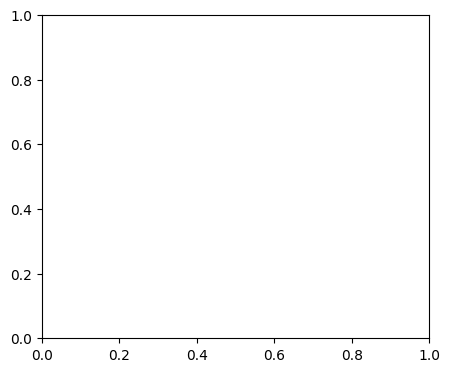

In [ ]:
fig, axs = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4.2))
for ax, (name, d) in zip(axs, samples.items()):
    step = d['ebsd']['meta']['xstep']
    ny, nx = d['quartz_mask'].shape
    extent = [0, nx * step, ny * step, 0]
    ax.imshow(d['quartz_mask'], cmap='gray', extent=extent)
    ax.set_title(f"{name}\nφ(Qtz) = {d['phi_quartz']:.3f}, {ny}×{nx} @ {step} µm")
    ax.set_xlabel('µm'); ax.set_ylabel('µm')
fig.tight_layout()

## Isotropic Torquato descriptors via porespy

All of S₂(r), L(z), pore-size F(r), and chord length on the quartz
binary mask — one line per descriptor per sample.

In [ ]:
import scipy.ndimage as ndi

# Common plotting range in physical units. Set this to the scale you care
# about (grain-size, ribbon-width range). It caps all plot x-axes; each
# sample still computes its descriptors on its full extent.
R_MAX_UM = 150.0
CHORD_MAX_UM = 200.0   # chord-length plot upper bound

def max_r_px(mask, frac=0.25):
    return int(min(mask.shape) * frac)

iso = {}
for name, d in samples.items():
    mask = d['quartz_mask']
    step = d['ebsd']['meta']['xstep']
    maxr = max_r_px(mask)

    # S2(r)
    s2 = ps.metrics.two_point_correlation(mask)
    # F(r) pore-size (via distance transform)
    dt = ndi.distance_transform_edt(mask)
    psd = ps.metrics.pore_size_distribution(dt, log=False, bins=50)
    # Chord length in x and y — use default spacing=1 so adjacent-row chords
    # don't get connected-component-merged into one giant blob.
    # NOTE: porespy's axis=0 means chords oriented along dim 0 = vertical.
    chords_y = ps.filters.apply_chords(mask, axis=0)
    chords_x = ps.filters.apply_chords(mask, axis=1)
    cld_y = ps.metrics.chord_length_distribution(chords_y, bins=40, log=False)
    cld_x = ps.metrics.chord_length_distribution(chords_x, bins=40, log=False)
    # Omnidirectional chord length survival (instead of porespy's
    # lineal_path_distribution, which returns an internal quantity in a
    # sub-pixel bin range that doesn't correspond to Torquato L(z)).
    # Manually combine x and y chord lengths into a single distribution.
    from scipy.ndimage import label as _label
    lbl_x, _ = _label(chords_x)
    lbl_y, _ = _label(chords_y)
    sizes = np.concatenate([
        np.bincount(lbl_x.ravel())[1:],
        np.bincount(lbl_y.ravel())[1:],
    ])
    sizes = sizes[sizes > 0]
    sizes_sorted = np.sort(sizes)
    # Survival function: P(chord length > z), evaluated at each distinct length.
    L_omni = sizes_sorted.astype(np.float64)
    survival_omni = 1.0 - np.arange(len(L_omni), dtype=np.float64) / len(L_omni)
    # Keep it plottable: subsample if too many points
    if len(L_omni) > 2000:
        idx = np.linspace(0, len(L_omni) - 1, 2000).astype(int)
        L_omni = L_omni[idx]
        survival_omni = survival_omni[idx]

    iso[name] = dict(s2=s2, psd=psd, cld_x=cld_x, cld_y=cld_y,
                      L_omni=L_omni, surv_omni=survival_omni,
                      maxr=maxr, step=step, phi=d['phi_quartz'])

print('descriptor suite computed for:', list(iso.keys()))
print(f'  plot range: r <= {R_MAX_UM:.0f} µm (set by R_MAX_UM);'
      f' chord <= {CHORD_MAX_UM:.0f} µm')

descriptor suite computed for: ['GrainMapS52']
  plot range: r <= 150 µm (set by R_MAX_UM); chord <= 200 µm


/Users/amasaryk/miniforge/envs/xsmurf/lib/python3.12/site-packages/porespy/metrics/_funcs.py:1154: FutureWarning: `RegionProperties.filled_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_filled` instead. 
  chord_lens = np.array([i.filled_area for i in props], dtype=int)


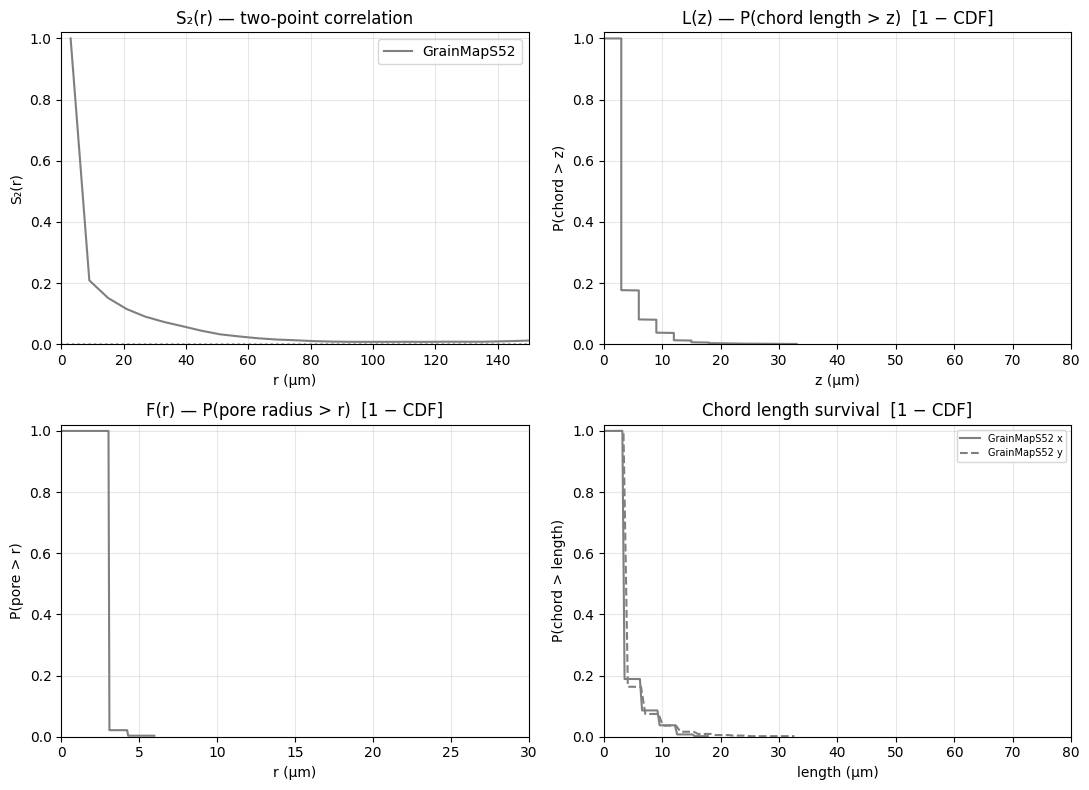

In [ ]:
# S2(r), L(z), F(r), chord-length overlays across samples
# Style key: same base colour for tiles of the same sample, lighter/darker
# by tile index so Proto_tile1 and Proto_tile2 are visually paired.
import matplotlib.colors as mcolors
_BASE_COLOUR = {'Protomylonite': 'tab:blue',
                 'Mylonite':      'tab:orange',
                 'Ultramylonite': 'tab:red'}
def sample_style(name):
    base, sep, tile = name.partition('_tile')
    base_c = _BASE_COLOUR.get(base, 'tab:gray')
    if not sep:
        return base_c, '-'
    rgb = np.array(mcolors.to_rgb(base_c))
    tile_n = int(tile)
    # tile 1 bright, tile 2 ~60% brightness; both solid lines
    shade = 1.0 if tile_n == 1 else 0.55
    return tuple(shade * rgb), '-'

fig, axs = plt.subplots(2, 2, figsize=(11, 8))

for name, r in iso.items():
    step = r['step']
    col, ls = sample_style(name)
    axs[0, 0].plot(r['s2'].distance * step, r['s2'].probability,
                    label=name, color=col, ls=ls)
    # L(z): omnidirectional chord-length survival we computed manually.
    # Prepend (0, 1) so the curve visibly starts at the origin.
    L_z = np.concatenate([[0.0], r['L_omni'] * step])
    surv_z = np.concatenate([[1.0], r['surv_omni']])
    axs[0, 1].plot(L_z, surv_z, label=name, color=col, ls=ls)

    # F(r) and chord-length: porespy's .cdf IS the survival function
    # (defined as 1 - cumsum(pdf)), so plot it DIRECTLY — my earlier
    # `1 - cdf` was inverting it back into a traditional CDF.
    R_pore = np.concatenate([[0.0], r['psd'].R * step])
    S_pore = np.concatenate([[1.0], r['psd'].cdf])
    axs[1, 0].plot(R_pore, S_pore, label=name, color=col, ls=ls)

    Lx = np.concatenate([[0.0], r['cld_x'].L * step])
    Sx = np.concatenate([[1.0], r['cld_x'].cdf])
    Ly = np.concatenate([[0.0], r['cld_y'].L * step])
    Sy = np.concatenate([[1.0], r['cld_y'].cdf])
    axs[1, 1].plot(Lx, Sx, '-',  label=f'{name} x', color=col)
    axs[1, 1].plot(Ly, Sy, '--', label=f'{name} y', color=col)

axs[0, 0].set_title('S₂(r) — two-point correlation'); axs[0, 0].set_xlabel('r (µm)')
axs[0, 0].set_ylabel('S₂(r)'); axs[0, 0].legend()
phi_max = max(iso[n]['phi'] for n in iso)
axs[0, 0].axhline(phi_max ** 2, ls=':', color='k', alpha=0.3)

axs[0, 1].set_title('L(z) — P(chord length > z)  [1 − CDF]')
axs[0, 1].set_xlabel('z (µm)'); axs[0, 1].set_ylabel('P(chord > z)')

axs[1, 0].set_title('F(r) — P(pore radius > r)  [1 − CDF]')
axs[1, 0].set_xlabel('r (µm)'); axs[1, 0].set_ylabel('P(pore > r)')

axs[1, 1].set_title('Chord length survival  [1 − CDF]')
axs[1, 1].set_xlabel('length (µm)'); axs[1, 1].set_ylabel('P(chord > length)')
axs[1, 1].legend(fontsize=7)

# x-axis ranges tuned to each descriptor's natural scale
axs[0, 0].set_xlim(0, R_MAX_UM)
axs[0, 1].set_xlim(0, 80)          # chords rarely exceed a grain diameter
axs[1, 0].set_xlim(0, 30)          # pore-radii are much smaller still
axs[1, 1].set_xlim(0, 80)

for a in axs.ravel(): a.grid(True, alpha=0.3); a.set_ylim(0, 1.02)
axs[0, 0].set_ylim(0, 1.02)        # S₂ already 0-1
fig.tight_layout()

## Anisotropic S₂(r, θ)

Porespy's built-in is radially averaged. For the directional version we
do FFT autocorrelation on the binary mask, then bin the 2D
autocorrelation by polar (r, θ). This mirrors what `compute_s2_directional`
in the companion `yield_surface_npoint` notebook does — kept inline here
so the notebook is self-contained.

In [ ]:
def s2_rtheta(mask, max_r, n_theta=36):
    # Anisotropic, *unbiased* S2(r, theta) via FFT autocorrelation of the
    # binary mask, normalised by the number of valid pairs at each lag.
    # With zero-padding, the overlap at lag (ry, rx) is (ny-ry)*(nx-rx),
    # not (ny*nx) — so dividing by the grid size as a global constant
    # biases S2 low by that geometric factor. The fix is to compute a
    # second autocorrelation of an all-ones support mask and divide.
    mask = mask.astype(np.float64)
    ny, nx = mask.shape
    padded_mask = np.zeros((2*ny, 2*nx))
    padded_mask[:ny, :nx] = mask
    padded_support = np.zeros((2*ny, 2*nx))
    padded_support[:ny, :nx] = 1.0
    F_m = fft2(padded_mask); F_s = fft2(padded_support)
    num = np.real(ifft2(F_m * np.conj(F_m)))
    den = np.real(ifft2(F_s * np.conj(F_s)))
    # Guard against near-zero denominators at lags beyond the image extent
    ac = num / np.maximum(den, 0.5)
    # Sample at small positive lags in the (r, theta) grid
    thetas = np.linspace(0, np.pi, n_theta, endpoint=False)
    rs = np.arange(0, max_r + 1)
    S2 = np.zeros((len(rs), n_theta))
    for ti, th in enumerate(thetas):
        cos_t, sin_t = np.cos(th), np.sin(th)
        for ri, r in enumerate(rs):
            dx = r * cos_t; dy = r * sin_t
            i0, j0 = int(np.floor(dy)), int(np.floor(dx))
            fi, fj = dy - i0, dx - j0
            # Bilinear interp within the padded autocorrelation (indices mod size)
            def _fetch(di, dj):
                return ac[(i0 + di) % (2*ny), (j0 + dj) % (2*nx)]
            S2[ri, ti] = ((1-fi)*(1-fj)*_fetch(0,0) + fi*(1-fj)*_fetch(1,0)
                          + (1-fi)*fj*_fetch(0,1) + fi*fj*_fetch(1,1))
    return S2, rs, thetas

def corr_length(S2_rth, rs, phi):
    # Integral correlation length, per direction:
    #   xi(theta) = (1/(phi - phi^2)) * integral_0^rmax (S2(r, theta) - phi^2) dr
    # The area under S2's decay to its asymptote phi^2, normalised so that
    # for a simple exponential S2(r) = phi^2 + (phi - phi^2) exp(-r/xi),
    # this integral equals xi. Robust to the noisy threshold-crossing
    # that was producing angular spikes for high-φ samples.
    baseline = phi * phi
    delta = np.maximum(S2_rth - baseline, 0.0)   # clip negatives from noise
    denom = max(phi - baseline, 1e-12)
    xi = np.trapezoid(delta, rs, axis=0) / denom
    return xi

In [ ]:
s2_aniso = {}
for name, d in samples.items():
    mask = d['quartz_mask']
    maxr = max_r_px(mask, frac=0.20)
    S2, rs, ths = s2_rtheta(mask, maxr, n_theta=36)
    cl = corr_length(S2, rs, d['phi_quartz'])
    s2_aniso[name] = dict(S2=S2, r=rs, theta=ths, corr_len=cl, maxr=maxr)
    print(f'{name:<14s}  S2(0)={S2[0, 0]:.3f} (=φ)'
          f'   corr length range {np.nanmin(cl):.1f}–{np.nanmax(cl):.1f} px')

GrainMapS52     S2(0)=0.010 (=φ)   corr length range 1.9–2.2 px


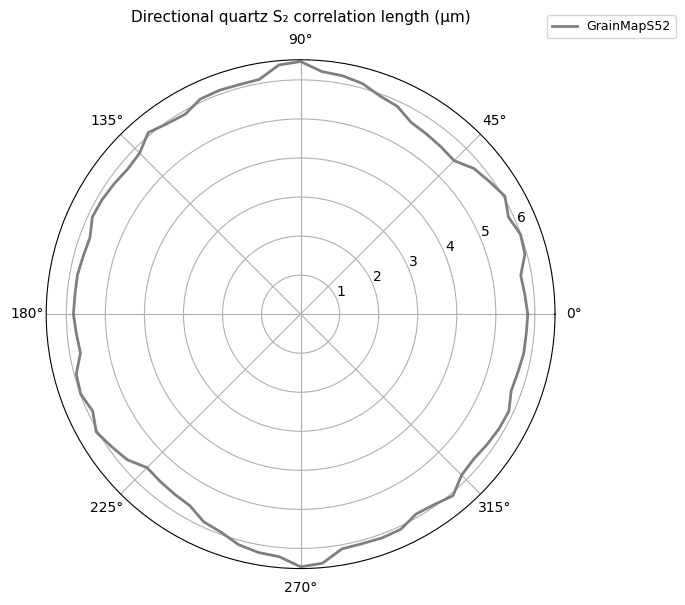

In [ ]:
# Polar plot of directional correlation length — anisotropy of the quartz fabric
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='polar')
for name, d in s2_aniso.items():
    # Extend to 360° so the curve closes
    theta_full = np.concatenate([d['theta'], d['theta'] + np.pi, d['theta'][:1]])
    cl_full    = np.concatenate([d['corr_len'], d['corr_len'], d['corr_len'][:1]])
    step = samples[name]['ebsd']['meta']['xstep']
    col, _ = sample_style(name)
    ax.plot(theta_full, cl_full * step, label=name, color=col, lw=2)
ax.set_title('Directional quartz S₂ correlation length (µm)',
              va='bottom', fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=9)
fig.tight_layout()

## Misorientation-aware grain reconstruction

The raw `scipy.ndimage.label(quartz_mask)` sees only two things: quartz
pixels and non-quartz pixels. Grain boundaries **inside the quartz
phase** are misorientation boundaries between same-phase pixels — they
don't show up in the phase mask at all, so connected-component
labelling on the mask merges hundreds of grains into a handful of
topologically-connected blobs. That's technically the right Torquato
C₂ on the phase indicator, but it's not what you'd call "grain count".

`grain_reconstruction()` below builds the MTEX-style grain map:
connected components on a graph where two same-phase pixels are linked
iff their symmetry-reduced misorientation is below 10°. Trigonal D3
symmetry for quartz, so Dauphiné twin boundaries (60° about c) count
as genuine boundaries.

In [ ]:
def grain_reconstruction(ebsd, phase_id=1, symmetry='D3',
                         threshold_deg=10.0, connectivity=8):
    # MTEX-style grain labelling via connected components on a
    # misorientation-thresholded graph.
    from orix.quaternion import Orientation
    from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh
    from scipy.sparse import coo_matrix
    from scipy.sparse.csgraph import connected_components

    sym_map = {'C1': C1, 'C2': C2, 'D2': D2, 'D3': D3,
               'D6': D6, 'C4': C4, 'Oh': Oh}
    sym = sym_map[symmetry]

    phase = ebsd['phase']
    ny, nx = phase.shape
    N = ny * nx
    in_phase = (phase == phase_id)
    if in_phase.sum() < 2:
        return np.zeros((ny, nx), dtype=np.int32)

    euler_rad = np.deg2rad(np.stack(
        [ebsd['euler1'], ebsd['euler2'], ebsd['euler3']], axis=-1
    ).astype(np.float64))
    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=sym)
    ori = ori.reshape(ny, nx)
    threshold_rad = np.deg2rad(threshold_deg)

    shifts = [(0, 1), (1, 0)]
    if connectivity == 8:
        shifts += [(1, 1), (1, -1)]

    edge_rows, edge_cols = [], []
    for di, dj in shifts:
        i0 = max(0, -di); i1 = min(ny, ny - di)
        j0 = max(0, -dj); j1 = min(nx, nx - dj)
        if i0 >= i1 or j0 >= j1:
            continue
        a = ori[i0:i1, j0:j1]
        b = ori[i0+di:i1+di, j0+dj:j1+dj]
        a_p = in_phase[i0:i1, j0:j1]
        b_p = in_phase[i0+di:i1+di, j0+dj:j1+dj]
        mis = a * (~b)
        ang = np.asarray(mis.angle)
        keep = a_p & b_p & (ang < threshold_rad)
        if np.any(keep):
            ii, jj = np.nonzero(keep)
            u = ((i0 + ii) * nx + (j0 + jj)).astype(np.int64)
            v = ((i0 + ii + di) * nx + (j0 + jj + dj)).astype(np.int64)
            edge_rows.append(u); edge_cols.append(v)

    if not edge_rows:
        gid = np.zeros((ny, nx), dtype=np.int32)
        indexed = in_phase.ravel()
        gid.flat[indexed] = np.arange(1, indexed.sum() + 1)
        return gid

    r = np.concatenate(edge_rows); c = np.concatenate(edge_cols)
    adj = coo_matrix((np.ones(len(r)*2, dtype=np.int8),
                      (np.concatenate([r, c]), np.concatenate([c, r]))),
                     shape=(N, N)).tocsr()
    _, labels = connected_components(adj, directed=False)
    # Compact grain IDs 1..N_grains for indexed pixels
    indexed = in_phase.ravel()
    gid_flat = np.zeros(N, dtype=np.int32)
    if indexed.any():
        _, compact = np.unique(labels[indexed], return_inverse=True)
        gid_flat[indexed] = compact + 1
    return gid_flat.reshape(ny, nx)

In [ ]:
# Compute misorientation-based grain maps for each sample at 10° threshold.
# Attach to the samples dict so downstream cells can reuse.
import time
for name, d in samples.items():
    t0 = time.perf_counter()
    gid = grain_reconstruction(d['ebsd'], phase_id=d['quartz_id'],
                                 symmetry='D3', threshold_deg=10.0)
    n_grains = int(gid.max())
    dt = time.perf_counter() - t0
    d['grain_id']   = gid
    d['n_grains']   = n_grains
    # Per-pixel grain size for later plots
    sizes = np.bincount(gid.ravel())
    d['grain_size_map'] = sizes[gid].astype(np.float32)
    d['grain_size_map'][gid == 0] = np.nan
    print(f'{name:<22s}  {n_grains:5d} grains @ 10° (quartz)'
          f'   median size = {np.median(sizes[1:]):.0f} px'
          f'   ({dt:.1f} s)')

GrainMapS52               843 grains @ 10° (quartz)   median size = 1 px   (0.4 s)


Error: IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed
[31m---------------------------------------------------------------------------[39m
[31mIndexError[39m                                Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[28][39m[32m, line 17[39m
[32m     13[39m     ncol = d[[33m'n_grains'[39m] + [32m1[39m
[32m     14[39m     palette = np.vstack([[[32m0[39m, [32m0[39m, [32m0[39m], rng.uniform([32m0.25[39m, [32m1.0[39m, (max(ncol - [32m1[39m, [32m1[39m), [32m3[39m))])
[32m     15[39m     cmap_g = mc.ListedColormap(palette)
[32m     16[39m 
[32m---> [39m[32m17[39m     axs[row, [32m0[39m].imshow(d[[33m'quartz_mask'[39m], cmap=[33m'gray'[39m, extent=extent)
[32m     18[39m     axs[row, [32m0[39m].set_title(f'{name}  quartz mask  (φ={d[[33m"phi_quartz"[39m]:.2f})')
[32m     19[39m     axs[row, [32m1[39m].imshow(gid, cmap=cmap_g, extent=extent)
[32m     20[39m     axs

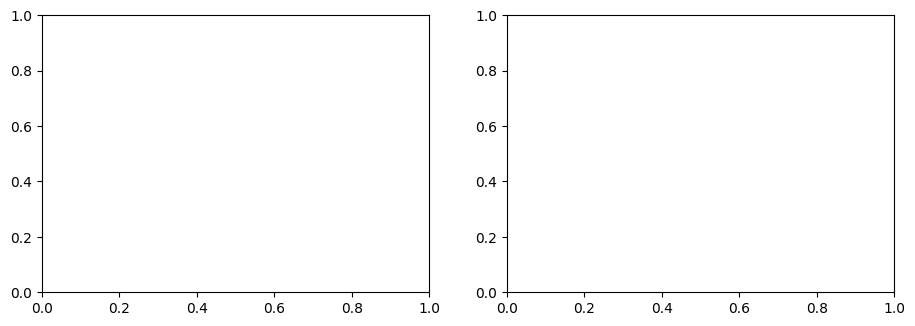

In [ ]:
# Visualise the grain map next to the quartz mask. Random colour per grain,
# unindexed = black. Compare to phase-mask-only clusters above.
import matplotlib.colors as mc

fig, axs = plt.subplots(len(samples), 2, figsize=(11, 3.6 * len(samples)))
for row, (name, d) in enumerate(samples.items()):
    step = d['ebsd']['meta']['xstep']
    gid = d['grain_id']
    ny, nx = gid.shape
    extent = [0, nx * step, ny * step, 0]
    # Random colours
    rng = np.random.default_rng(0)
    ncol = d['n_grains'] + 1
    palette = np.vstack([[0, 0, 0], rng.uniform(0.25, 1.0, (max(ncol - 1, 1), 3))])
    cmap_g = mc.ListedColormap(palette)

    axs[row, 0].imshow(d['quartz_mask'], cmap='gray', extent=extent)
    axs[row, 0].set_title(f'{name}  quartz mask  (φ={d["phi_quartz"]:.2f})')
    axs[row, 1].imshow(gid, cmap=cmap_g, extent=extent)
    axs[row, 1].set_title(f'grain map  ({d["n_grains"]} grains @ 10°)')
    for a in axs[row]: a.set_xlabel('µm'); a.set_ylabel('µm')
fig.tight_layout()

## C₂(r) cluster function and C₂/S₂ connectivity ratio

For each quartz-mask, label connected components, sum the FFT
autocorrelation of each component, and normalise so C₂(0) = φ (same
as S₂). The ratio C₂/S₂ is the probability of being in the *same*
cluster given both pixels are in quartz.

**Expected behaviour**:
- If quartz is one big connected framework, C₂/S₂ ≈ 1 at all r.
- If quartz breaks into N smaller clusters of typical size ξ, then
  C₂/S₂ drops to roughly 1/⟨#clusters visible at scale r⟩ beyond ξ.

In [ ]:
def c2_rtheta_from_label(label_map, max_r, n_theta=36, min_cluster_px=4):
    # Cluster two-point function: sum of per-cluster FFT autocorrelations,
    # normalised by the pair-count support the same way as s2_rtheta
    # (unbiased at all lags). Takes a pre-computed label map where
    # 1..N = clusters and 0 = background.
    ny, nx = label_map.shape
    num_total = np.zeros((2*ny, 2*nx))
    # Single support autocorrelation (image extent): pairs-per-lag count.
    padded_support = np.zeros((2*ny, 2*nx))
    padded_support[:ny, :nx] = 1.0
    F_s = fft2(padded_support)
    den = np.real(ifft2(F_s * np.conj(F_s)))

    kept_clusters = 0
    total_px = 0
    n_clusters = int(label_map.max())
    sizes = np.bincount(label_map.ravel(), minlength=n_clusters + 1)
    for cid in range(1, n_clusters + 1):
        if sizes[cid] < min_cluster_px:
            continue
        cl = (label_map == cid)
        padded = np.zeros((2*ny, 2*nx))
        padded[:ny, :nx] = cl.astype(np.float64)
        F = fft2(padded)
        num_total += np.real(ifft2(F * np.conj(F)))
        kept_clusters += 1
        total_px += int(sizes[cid])
    ac_total = num_total / np.maximum(den, 0.5)

    thetas = np.linspace(0, np.pi, n_theta, endpoint=False)
    rs = np.arange(0, max_r + 1)
    C2 = np.zeros((len(rs), n_theta))
    for ti, th in enumerate(thetas):
        cos_t, sin_t = np.cos(th), np.sin(th)
        for ri, r in enumerate(rs):
            dx = r * cos_t; dy = r * sin_t
            i0, j0 = int(np.floor(dy)), int(np.floor(dx))
            fi, fj = dy - i0, dx - j0
            def _fetch(di, dj):
                return ac_total[(i0 + di) % (2*ny), (j0 + dj) % (2*nx)]
            C2[ri, ti] = ((1-fi)*(1-fj)*_fetch(0,0) + fi*(1-fj)*_fetch(1,0)
                          + (1-fi)*fj*_fetch(0,1) + fi*fj*_fetch(1,1))
    return C2, rs, thetas, kept_clusters, total_px

# Backwards-compatible wrapper: feed it a binary mask, get phase-mask C2.
def c2_rtheta(mask, max_r, n_theta=36, min_cluster_px=4):
    # Torquato C2 on the phase mask itself — a few giant clusters when
    # φ is high. Used as the "phase-mask connectivity" reference.
    labels, _ = label(mask.astype(bool))
    return c2_rtheta_from_label(labels, max_r, n_theta, min_cluster_px)

In [ ]:
# Two parallel C2 analyses:
#   - phase-mask C2: topological clusters of the binary quartz mask.
#     High-φ samples produce a few giant clusters → C2/S2 stays ≈ 1 at all r.
#   - grain-wise C2: MTEX-style, each misorientation-bounded grain is its
#     own cluster. This gives ~hundreds of small clusters and a proper
#     decay profile in C2/S2 that reflects grain-scale connectivity.
c2 = {}
for name, d in samples.items():
    maxr = s2_aniso[name]['maxr']
    # Phase-mask version (Torquato reference)
    C2_ph, rs, ths, n_cl_ph, n_px_ph = c2_rtheta(d['quartz_mask'], maxr, n_theta=36)
    # Grain-wise version (MTEX-style, uses the misorientation grain_id)
    C2_g, _, _, n_cl_g, n_px_g = c2_rtheta_from_label(d['grain_id'], maxr, n_theta=36)
    c2[name] = dict(C2_phase=C2_ph, C2_grain=C2_g,
                     r=rs, theta=ths,
                     n_clusters_phase=n_cl_ph, n_clusters_grain=n_cl_g,
                     total_px=n_px_ph)
    print(f'{name:<22s}  phase clusters={n_cl_ph:5d}   grain clusters={n_cl_g:5d}'
          f'   C2_phase(0)={C2_ph[0,0]:.3f}  C2_grain(0)={C2_g[0,0]:.3f}')

Protomylonite_tile1     phase clusters=    6   grain clusters=  509   C2_phase(0)=0.955  C2_grain(0)=0.944
Protomylonite_tile2     phase clusters=  303   grain clusters=  702   C2_phase(0)=0.837  C2_grain(0)=0.828
Mylonite_tile1          phase clusters=   97   grain clusters= 1030   C2_phase(0)=0.884  C2_grain(0)=0.869
Mylonite_tile2          phase clusters=   74   grain clusters= 1028   C2_phase(0)=0.903  C2_grain(0)=0.888
Ultramylonite           phase clusters=  595   grain clusters=  773   C2_phase(0)=0.230  C2_grain(0)=0.228


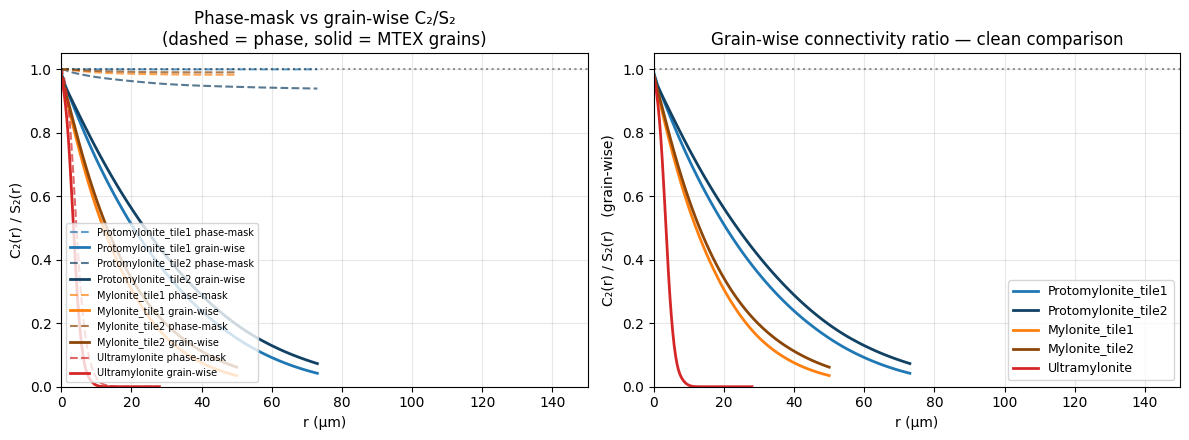

In [ ]:
# Plot: C2/S2 ratio vs r (θ-averaged), for both definitions
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for name, d in samples.items():
    step = samples[name]['ebsd']['meta']['xstep']
    C2_ph = c2[name]['C2_phase']; C2_g = c2[name]['C2_grain']
    S2    = s2_aniso[name]['S2']
    rs    = c2[name]['r']
    S2_iso    = S2.mean(axis=1)
    ratio_ph  = C2_ph.mean(axis=1) / np.maximum(S2_iso, 1e-12)
    ratio_g   = C2_g.mean(axis=1)  / np.maximum(S2_iso, 1e-12)
    col, _ = sample_style(name)
    axs[0].plot(rs * step, ratio_ph, ls='--', color=col, alpha=0.7,
                label=f'{name} phase-mask')
    axs[0].plot(rs * step, ratio_g,  ls='-',  color=col, lw=2,
                label=f'{name} grain-wise')
    axs[1].plot(rs * step, ratio_g,  ls='-',  color=col, lw=2, label=name)

for a in axs:
    a.axhline(1.0, ls=':', color='k', alpha=0.4)
    a.set_xlabel('r (µm)'); a.set_ylim(0, 1.05); a.set_xlim(0, R_MAX_UM)
    a.grid(True, alpha=0.3)
axs[0].set_ylabel('C₂(r) / S₂(r)')
axs[0].set_title('Phase-mask vs grain-wise C₂/S₂\n(dashed = phase, solid = MTEX grains)')
axs[0].legend(fontsize=7, loc='lower left')
axs[1].set_ylabel('C₂(r) / S₂(r)   (grain-wise)')
axs[1].set_title('Grain-wise connectivity ratio — clean comparison')
axs[1].legend(fontsize=9)
fig.tight_layout()

### Anisotropic C₂/S₂ — does quartz connectivity depend on direction?

The isotropic version above averages out the fabric anisotropy. Since
mylonitic quartz ribbons are preferentially oriented, the connectivity
ratio should drop faster **across** the foliation than along it for
samples whose ribbons are still intact. A sample where connectivity
becomes isotropic has lost the ribbon structure.

Text(0.5, 1.02, 'Directional connectivity ratio C₂(r, θ) / S₂(r, θ)')

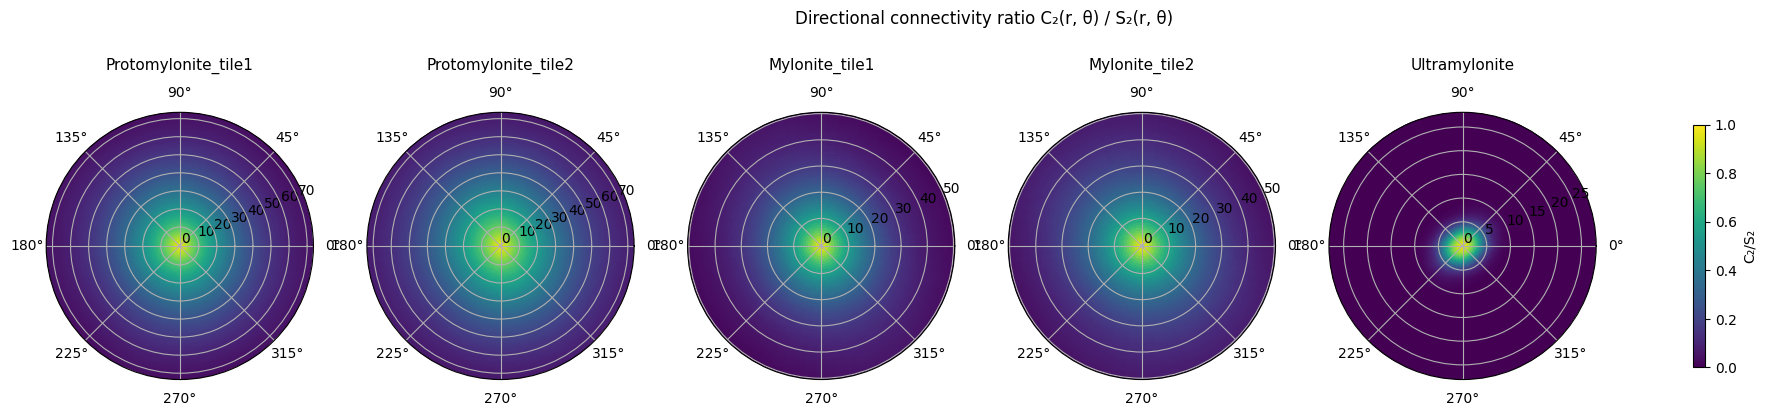

In [131]:
fig, axs = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4.5),
                         subplot_kw={'projection': 'polar'})
if len(samples) == 1: axs = [axs]
for ax, (name, d) in zip(axs, samples.items()):
    step = d['ebsd']['meta']['xstep']
    C2 = c2[name]['C2_grain']; S2 = s2_aniso[name]['S2']
    rs = c2[name]['r']; ths = c2[name]['theta']
    ratio = C2 / np.maximum(S2, 1e-12)
    # Extend theta to 2π by mirror symmetry (ratio is direction-line invariant)
    theta_full = np.concatenate([ths, ths + np.pi])
    R_grid, TH_grid = np.meshgrid(rs * step,
                                    np.concatenate([ths, ths + np.pi]),
                                    indexing='ij')
    ratio_full = np.concatenate([ratio, ratio], axis=1)
    pcm = ax.pcolormesh(TH_grid, R_grid, ratio_full,
                        cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.set_title(name, fontsize=11, pad=12)
fig.colorbar(pcm, ax=axs, shrink=0.7, label='C₂/S₂')
fig.suptitle('Directional connectivity ratio C₂(r, θ) / S₂(r, θ)',
             fontsize=12, y=1.02)

## Summary table

One row per sample: quartz volume fraction, number of clusters,
mean/max grain connectivity, correlation-length anisotropy, and the
half-radius of the C₂/S₂ ratio (the lag at which C₂/S₂ = 0.5,
equivalent to the scale beyond which half of the quartz-quartz pairs
are in *different* clusters).

In [132]:
def c_over_s_halfradius(c2_iso, s2_iso, rs, step):
    # Return r (µm) where C2/S2 first drops below 0.5.
    ratio = c2_iso / np.maximum(s2_iso, 1e-12)
    below = np.where(ratio < 0.5)[0]
    if below.size == 0:
        return float('inf')
    return float(rs[below[0]] * step)

rows = []
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    cl = s2_aniso[name]['corr_len']
    cl_min, cl_max = np.nanmin(cl) * step, np.nanmax(cl) * step
    aniso = cl_max / max(cl_min, 1e-9)
    # The meaningful half-radius is computed from the GRAIN-WISE C2,
    # since the phase-mask C2/S2 is ~1 everywhere for high-φ samples.
    c_iso = c2[name]['C2_grain'].mean(axis=1)
    s_iso = s2_aniso[name]['S2'].mean(axis=1)
    r_half = c_over_s_halfradius(c_iso, s_iso, c2[name]['r'], step)
    rows.append({
        'sample':       name,
        'phi_quartz':   d['phi_quartz'],
        'n_grains':     d['n_grains'],
        'n_clusters_phase': c2[name]['n_clusters_phase'],
        'corr_len_min_um': cl_min,
        'corr_len_max_um': cl_max,
        'anisotropy':      aniso,
        'c2_over_s2_halfradius_um': r_half,
    })

import pandas as pd
df = pd.DataFrame(rows).set_index('sample')
print(df.to_string(float_format=lambda x: f'{x:8.3f}'))

                     phi_quartz  n_grains  n_clusters_phase  corr_len_min_um  corr_len_max_um  anisotropy  c2_over_s2_halfradius_um
sample                                                                                                                             
Protomylonite_tile1       0.955      3032                 6            5.376           10.356       1.926                    21.000
Protomylonite_tile2       0.842      3532               303            5.639           13.671       2.425                    24.000
Mylonite_tile1            0.886      4322                97           10.442           13.258       1.270                    13.000
Mylonite_tile2            0.904      4421                74           11.441           14.709       1.286                    14.000
Ultramylonite             0.234      2920               595            1.397            2.263       1.620                     3.600


## Interpretation cribsheet

**If the KMZ deformation gradient is genuine** (Protomylonite → Mylonite
→ Ultramylonite = increasing strain):

- **φ(Qtz)**: should stay roughly constant if deformation is
  volumetrically conservative. Any large change flags either sampling
  bias or phase-specific transformations (dissolution-precipitation).
- **S₂ correlation length**: expected to **shorten** with strain as
  grain size reduces through recrystallisation. Tracks the mantle grain
  size in core-and-mantle microstructures.
- **S₂ anisotropy ratio**: expected to **increase** with strain as
  ribbons develop, *then* decrease again if ribbons break up in
  ultramylonite.
- **n_clusters**: should **increase** dramatically in the Ultramylonite
  if ribbons fragment; small in Proto/Mylonite where quartz is a
  connected framework.
- **C₂/S₂ half-radius**: the headline diagnostic. A **long** value
  means quartz connectivity extends far (ribbons intact); a **short**
  value means fragmentation. Predicted order:
  Protomylonite > Mylonite > Ultramylonite.

**If we see the opposite** (Ultramylonite has longer half-radius than
Mylonite): something unexpected. Either (a) the Ultramylonite was
sampled in a recrystallised domain where fine grains are all connected
because they're all touching, or (b) "Mylonite" is actually more
deformed than "Ultramylonite" and the sample naming reflects
microstructure rather than strain intensity.

## Caveats

- **Open boundary artefact**: porespy's two_point_correlation and our
  FFT approach both assume periodic images. Zero-padding mitigates but
  doesn't eliminate edge bias at large r. Don't trust r beyond ~1/4 of
  the shorter axis.
- **Different step sizes**: Protomylonite/Mylonite at 1 µm vs
  Ultramylonite at 0.2 µm. Plotting vs physical distance (µm) makes
  them directly comparable; pixel-level comparisons are NOT.
- **Quartz-only ignores mineralogy gradients**: if the Ultramylonite
  truly has more feldspar matrix than the Protomylonite, C₂/S₂
  differences may reflect mineralogical composition rather than
  strain-localisation mechanism. Can be tested by computing
  C₂/S₂ for all indexed phases in the Ultramylonite and seeing if
  quartz-specific connectivity is different from whole-sample
  connectivity.

In [133]:
from scipy import stats
import numpy as np

def fit_grain_size_family(sizes_um, tail_quantile=0.90):
    # Drop the smallest bin (1-pixel "grains" = indexing noise)
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]

    # --- 1) Full distribution: Generalised Gamma, MLE
    # scipy parameterisation: f(x) = |c|*x^(a*c - 1) * exp(-x^c) / (Γ(a) * scale^(ac))
    a, c, loc_gg, scale_gg = stats.gengamma.fit(x, floc=0)
    # Special cases:
    #   c ≈ 1  → Gamma
    #   a ≈ 1  → Weibull
    #   ac ≫ 1 + very spread a → Log-normal limit
    #   small c → heavy-tailed (power-law-like for small c)

    # --- 2) Tail: GPD via peaks-over-threshold
    u = np.quantile(x, tail_quantile)
    excesses = x[x > u] - u
    xi, loc_gpd, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    # xi > 0   Fréchet (heavy tail, nonextensive)
    # xi ≈ 0   Gumbel (exponential tail)
    # xi < 0   Weibull (bounded tail, upper bound = u - scale/xi)

    # --- 3) Diagnostic: mean-residual-life at a few thresholds.
    # Stability across thresholds is the MLE validity check.
    thresholds = np.quantile(x, [0.75, 0.85, 0.90, 0.95])
    xi_by_thr = []
    for uu in thresholds:
        ex = x[x > uu] - uu
        if len(ex) < 30: continue
        xi_i, _, _ = stats.genpareto.fit(ex, floc=0)
        xi_by_thr.append((float(uu), int(len(ex)), float(xi_i)))

    return {
        'gg': {'a': a, 'c': c, 'scale': scale_gg},
        'pot': {'threshold_um': float(u), 'xi': float(xi), 'scale': float(scale_gpd),
                'n_excess': int(len(excesses))},
        'xi_stability': xi_by_thr,    # list of (threshold, n, xi) for sensitivity check
    }

sample                 n_grains  median µm    GG a    GG c   thr µm    ξ (GPD)     regime
Protomylonite_tile1        1016       2.26  13.225   0.219    29.15     -0.359    Weibull
Protomylonite_tile2        1357       2.26  18.912   0.228    13.15     -0.135    Weibull
Mylonite_tile1             1638       2.76  13.584   0.264    20.66     -0.126    Weibull
Mylonite_tile2             1664       2.52  12.872   0.265    20.52      0.004     Gumbel
Ultramylonite              1193       0.64  13.551   0.269     4.00     -0.107    Weibull


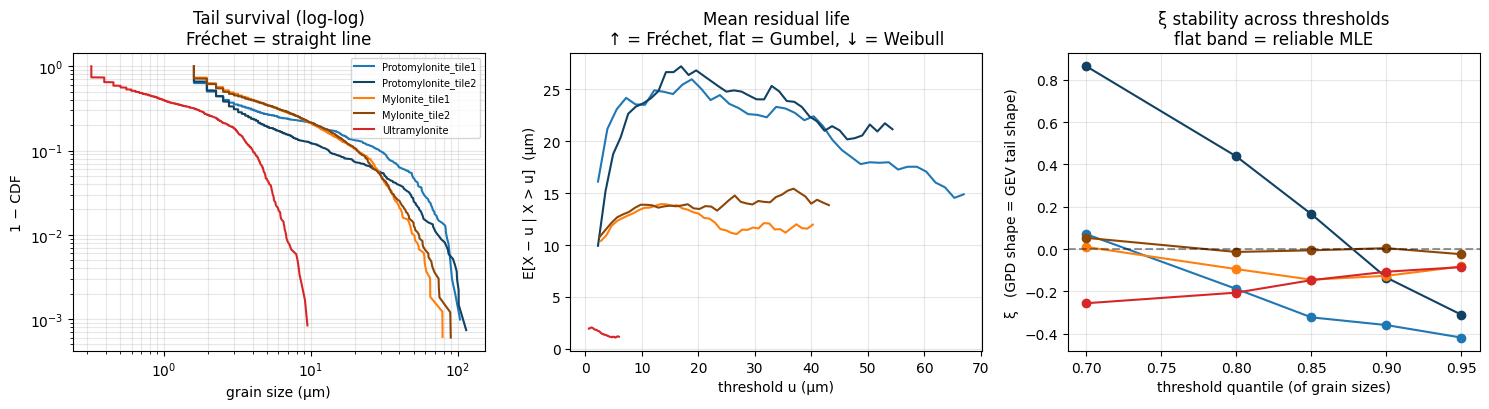

In [134]:
# ──────────────────────────────────────────────────────────────────────
# Bruce Hobbs' "Tsallis entropy" framework — grain size distributions
#   full distribution  →  Generalised Gamma (MLE)
#   tail               →  Generalised Pareto via peaks-over-threshold
#                          (GPD shape = GEV shape ξ)
# Predicted regime shift with increasing deformation:
#   Fréchet (ξ > 0, heavy tail, connected / nonextensive)
#   Gumbel  (ξ ≈ 0, exponential tail)
#   Weibull (ξ < 0, bounded tail, constrained)
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

def fit_grain_size_family(sizes_um, tail_quantile=0.90, min_excess=30):
    # Drop the bottom 2 % (single-pixel "grains" = indexing noise)
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]
    try:
        a_gg, c_gg, _, scale_gg = stats.gengamma.fit(x, floc=0)
    except Exception:
        a_gg = c_gg = scale_gg = np.nan

    u = np.quantile(x, tail_quantile)
    excesses = x[x > u] - u
    try:
        xi, _, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    except Exception:
        xi = scale_gpd = np.nan

    stability = []
    for q in (0.70, 0.80, 0.85, 0.90, 0.95):
        uu = np.quantile(x, q)
        ex = x[x > uu] - uu
        if len(ex) < min_excess:
            continue
        try:
            xi_i, _, sc_i = stats.genpareto.fit(ex, floc=0)
            stability.append((q, float(uu), len(ex), float(xi_i)))
        except Exception:
            pass

    return {'gg': (a_gg, c_gg, scale_gg), 'u': float(u), 'xi': float(xi),
            'scale_gpd': float(scale_gpd), 'n_excess': int(len(excesses)),
            'stability': stability, 'x': x}


# Per-sample fits
fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]   # drop label 0 (background)
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step         # equivalent-circle diameter (µm)
    fits[name] = fit_grain_size_family(ecd)

# Summary table
print(f"{'sample':<22s} {'n_grains':>8s} {'median µm':>10s} "
      f"{'GG a':>7s} {'GG c':>7s} {'thr µm':>8s} "
      f"{'ξ (GPD)':>10s} {'regime':>10s}")
for name, f in fits.items():
    a_gg, c_gg, _ = f['gg']
    xi = f['xi']
    regime = 'Fréchet' if xi > 0.05 else ('Weibull' if xi < -0.05 else 'Gumbel')
    print(f"{name:<22s} {len(f['x']):>8d} {np.median(f['x']):>10.2f} "
          f"{a_gg:>7.3f} {c_gg:>7.3f} {f['u']:>8.2f} "
          f"{xi:>10.3f} {regime:>10s}")

# Diagnostic plots
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for name, f in fits.items():
    col, _ = sample_style(name)
    x_sorted = np.sort(f['x'])
    surv = 1.0 - np.arange(len(x_sorted)) / len(x_sorted)
    ok = surv > 0
    axs[0].loglog(x_sorted[ok], surv[ok], '-', color=col, lw=1.5, label=name)

    # Mean residual life
    u_grid = np.linspace(np.quantile(f['x'], 0.50),
                         np.quantile(f['x'], 0.98), 40)
    mrl = np.array([np.mean(f['x'][f['x'] > uu] - uu)
                    if (f['x'] > uu).sum() > 20 else np.nan
                    for uu in u_grid])
    axs[1].plot(u_grid, mrl, '-', color=col, lw=1.5, label=name)

    # ξ stability across thresholds
    if f['stability']:
        qs, _us, _ns, xis = zip(*f['stability'])
        axs[2].plot(qs, xis, 'o-', color=col, lw=1.5, label=name)

axs[0].set_xlabel('grain size (µm)'); axs[0].set_ylabel('1 − CDF')
axs[0].set_title('Tail survival (log-log)\nFréchet = straight line')
axs[0].grid(True, which='both', alpha=0.3); axs[0].legend(fontsize=7)

axs[1].set_xlabel('threshold u (µm)'); axs[1].set_ylabel('E[X − u | X > u]  (µm)')
axs[1].set_title('Mean residual life\n↑ = Fréchet, flat = Gumbel, ↓ = Weibull')
axs[1].grid(True, alpha=0.3)

axs[2].axhline(0.0, ls='--', color='k', alpha=0.4)
axs[2].set_xlabel('threshold quantile (of grain sizes)')
axs[2].set_ylabel('ξ   (GPD shape = GEV tail shape)')
axs[2].set_title('ξ stability across thresholds\nflat band = reliable MLE')
axs[2].grid(True, alpha=0.3)
fig.tight_layout()

sample                      n  median µm   GG a   GG c   u (µm)        ξ     regime
Protomylonite_tile1      1016       2.26  13.22   0.22    29.15   -0.359    Weibull
Protomylonite_tile2      1357       2.26  18.91   0.23    13.15   -0.135    Weibull
Mylonite_tile1           1638       2.76  13.58   0.26    20.66   -0.126    Weibull
Mylonite_tile2           1664       2.52  12.87   0.27    20.52   +0.004     Gumbel
Ultramylonite            1193       0.64  13.55   0.27     4.00   -0.107    Weibull


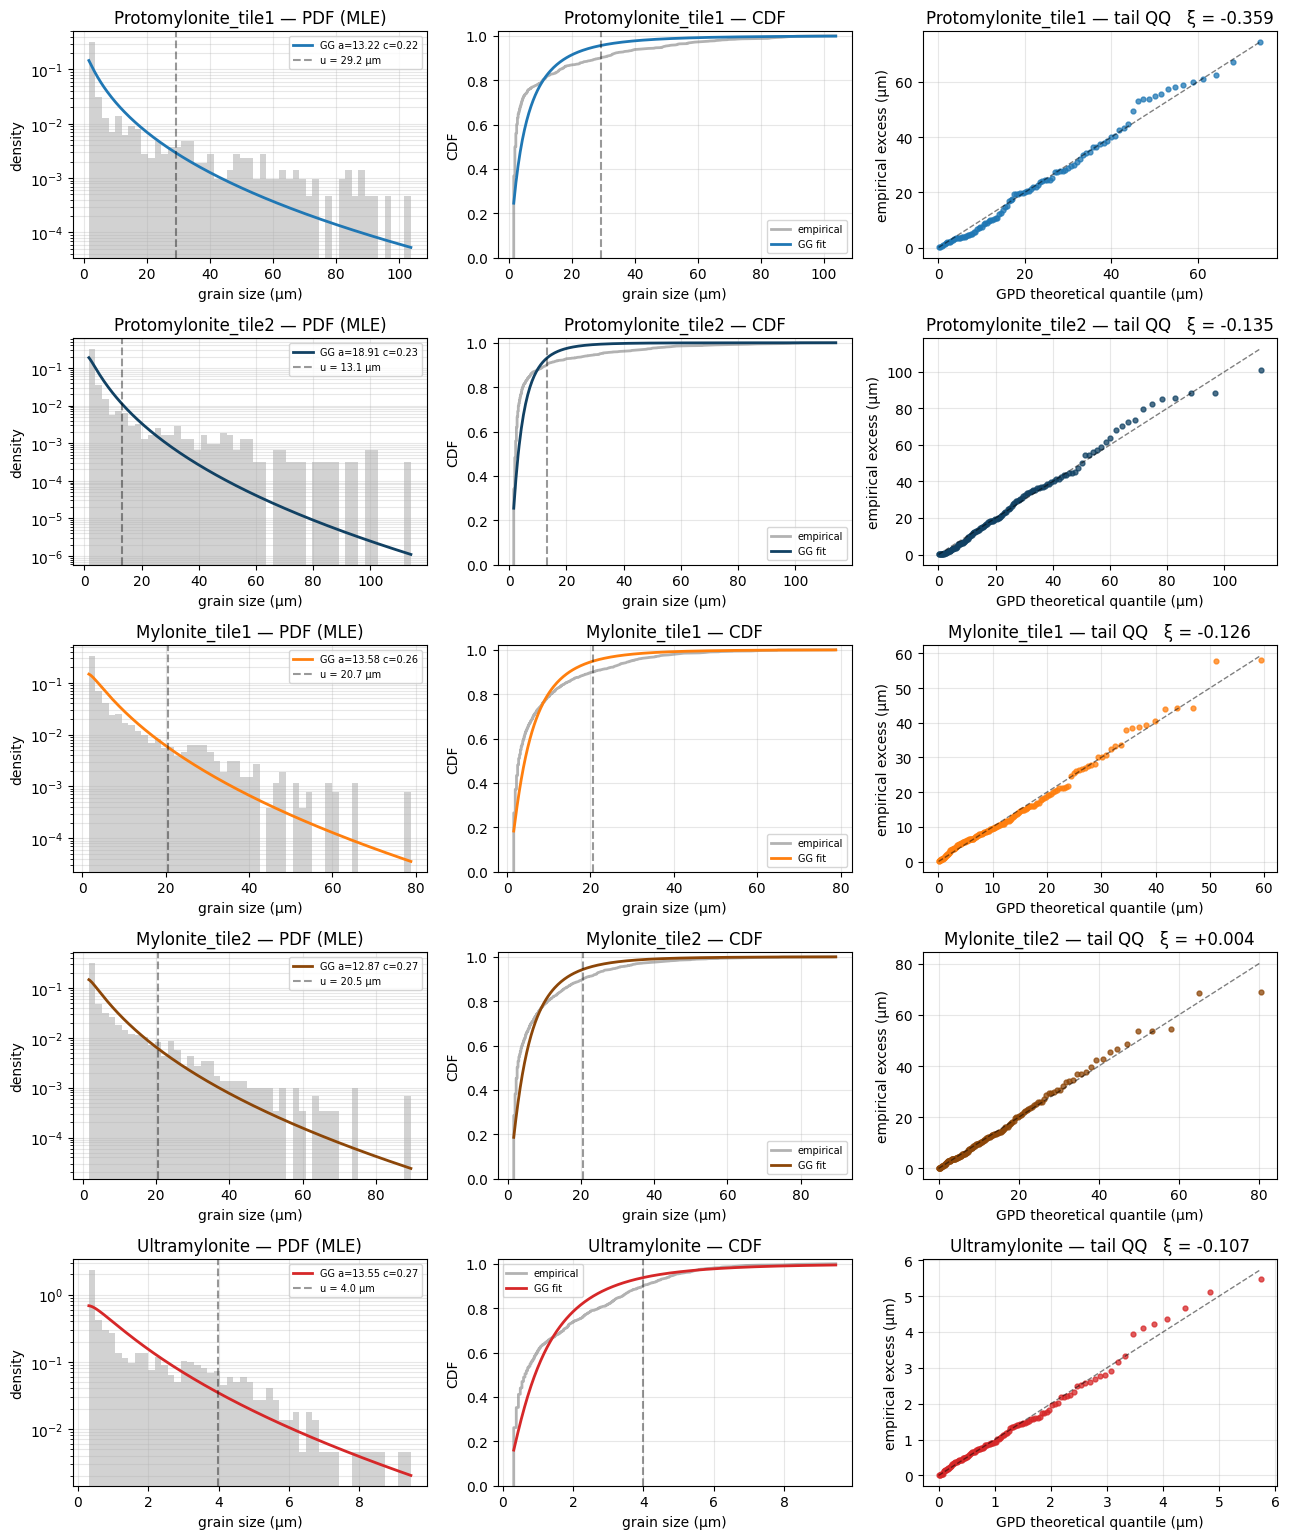

In [135]:
# ──────────────────────────────────────────────────────────────────────
# Standard MLE diagnostics for the Bruce Hobbs framework
#
#   PDF  — grain-size histogram (gray) vs fitted Generalised-Gamma density
#          (colour). On log-y, the fitted curve should hug the histogram
#          through the bulk; deviation in the far right tail is where the
#          GPD fit takes over.
#   CDF  — empirical step CDF (gray) vs fitted GG CDF (colour). Sustained
#          gaps = the GG doesn't describe that part of the distribution.
#   QQ   — sorted empirical EXCESSES above threshold u vs the corresponding
#          GPD theoretical quantiles. If GPD models the tail, points fall on
#          the y = x line. Points curving UP at the right = real tail heavier
#          than fit (still headed Fréchet-wards); curving DOWN = bounded /
#          Weibull-like tail.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats


def fit_grain_size_family(sizes_um, tail_quantile=0.90, min_excess=30):
    x = sizes_um[sizes_um > np.percentile(sizes_um, 2)]
    try:
        a_gg, c_gg, _, scale_gg = stats.gengamma.fit(x, floc=0)
    except Exception:
        a_gg = c_gg = scale_gg = np.nan
    u = float(np.quantile(x, tail_quantile))
    excesses = x[x > u] - u
    try:
        xi, _, scale_gpd = stats.genpareto.fit(excesses, floc=0)
    except Exception:
        xi = scale_gpd = np.nan
    return {'gg': (a_gg, c_gg, scale_gg), 'u': u, 'xi': float(xi),
            'scale_gpd': float(scale_gpd),
            'excesses': excesses, 'x': x, 'n_excess': int(len(excesses))}


# Per-sample fits
fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]    # drop label 0 = background
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step          # equivalent-circle diameter (µm)
    fits[name] = fit_grain_size_family(ecd)


# Summary table
print(f"{'sample':<22s} {'n':>6s} {'median µm':>10s} "
      f"{'GG a':>6s} {'GG c':>6s} {'u (µm)':>8s} "
      f"{'ξ':>8s} {'regime':>10s}")
for name, f in fits.items():
    a_gg, c_gg, _ = f['gg']
    xi = f['xi']
    regime = 'Fréchet' if xi > 0.05 else ('Weibull' if xi < -0.05 else 'Gumbel')
    print(f"{name:<22s} {len(f['x']):>6d} {np.median(f['x']):>10.2f} "
          f"{a_gg:>6.2f} {c_gg:>6.2f} {f['u']:>8.2f} "
          f"{xi:>+8.3f} {regime:>10s}")


# Per-sample diagnostic plots (5 rows × 3 cols)
n = len(fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, f) in enumerate(fits.items()):
    col, _ = sample_style(name)
    x = f['x']
    a, c, scale = f['gg']
    u, xi, scale_gpd = f['u'], f['xi'], f['scale_gpd']

    # ----- PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 50)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(max(x.min(), 1e-3), x.max(), 300)
    ax.plot(xr, stats.gengamma.pdf(xr, a, c, scale=scale),
            '-', color=col, lw=2, label=f'GG a={a:.2f} c={c:.2f}')
    ax.axvline(u, ls='--', color='k', alpha=0.4, label=f'u = {u:.1f} µm')
    ax.set(xlabel='grain size (µm)', ylabel='density',
           title=f'{name} — PDF (MLE)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # ----- CDF
    ax = axs[row, 1]
    x_sorted = np.sort(x)
    cdf_emp = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    ax.plot(x_sorted, cdf_emp, '-', color='gray', lw=2, alpha=0.6, label='empirical')
    ax.plot(xr, stats.gengamma.cdf(xr, a, c, scale=scale),
            '-', color=col, lw=2, label='GG fit')
    ax.axvline(u, ls='--', color='k', alpha=0.4)
    ax.set(xlabel='grain size (µm)', ylabel='CDF',
           title=f'{name} — CDF')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # ----- QQ plot of the GPD-fit tail
    ax = axs[row, 2]
    excesses = np.sort(f['excesses'])
    if len(excesses) >= 5 and np.isfinite(xi) and np.isfinite(scale_gpd):
        n_ex = len(excesses)
        q_th = stats.genpareto.ppf((np.arange(1, n_ex + 1) - 0.5) / n_ex,
                                    xi, loc=0, scale=scale_gpd)
        ax.plot(q_th, excesses, 'o', color=col, ms=3.5, alpha=0.75)
        mn = min(q_th.min(), excesses.min())
        mx = max(q_th.max(), excesses.max())
        ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GPD theoretical quantile (µm)',
           ylabel='empirical excess (µm)',
           title=f'{name} — tail QQ   ξ = {xi:+.3f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

In [136]:
# Sanity checks: fit the three nested special cases and compare log-likelihoods
for name, f in fits.items():
    x = f['x']
    ll_gg   = stats.gengamma.logpdf(x, *f['gg'][:2], scale=f['gg'][2]).sum()
    p_w     = stats.weibull_min.fit(x, floc=0)
    ll_w    = stats.weibull_min.logpdf(x, *p_w).sum()
    p_g     = stats.gamma.fit(x, floc=0)
    ll_g    = stats.gamma.logpdf(x, *p_g).sum()
    p_ln    = stats.lognorm.fit(x, floc=0)
    ll_ln   = stats.lognorm.logpdf(x, *p_ln).sum()
    print(f"{name:<22s}  logL: GG={ll_gg:8.1f}  Weibull={ll_w:8.1f}  "
          f"Gamma={ll_g:8.1f}  LogN={ll_ln:8.1f}")

Protomylonite_tile1     logL: GG= -2977.9  Weibull= -3139.9  Gamma= -3199.9  LogN= -2917.0
Protomylonite_tile2     logL: GG= -3471.6  Weibull= -3783.3  Gamma= -3854.9  LogN= -3376.1
Mylonite_tile1          logL: GG= -4692.2  Weibull= -4903.2  Gamma= -4919.5  LogN= -4622.4
Mylonite_tile2          logL: GG= -4786.5  Weibull= -5000.8  Gamma= -5023.9  LogN= -4713.0
Ultramylonite           logL: GG= -1563.0  Weibull= -1663.2  Gamma= -1659.3  LogN= -1531.6


Ultramylonite: only 4 blocks — skipped
sample                  # blocks  block µm    GEV ξ   GEV loc  GEV scale    GPD ξ      regime
Protomylonite_tile1          105      50.0   -0.441     75.62      14.76   -0.359     Weibull
Protomylonite_tile2           98      50.0   -0.610     82.33      21.37   -0.135     Weibull
Mylonite_tile1                90      50.0   -0.208     47.93      14.27   -0.126     Weibull
Mylonite_tile2                95      50.0   -0.316     55.50      16.66   +0.004     Weibull


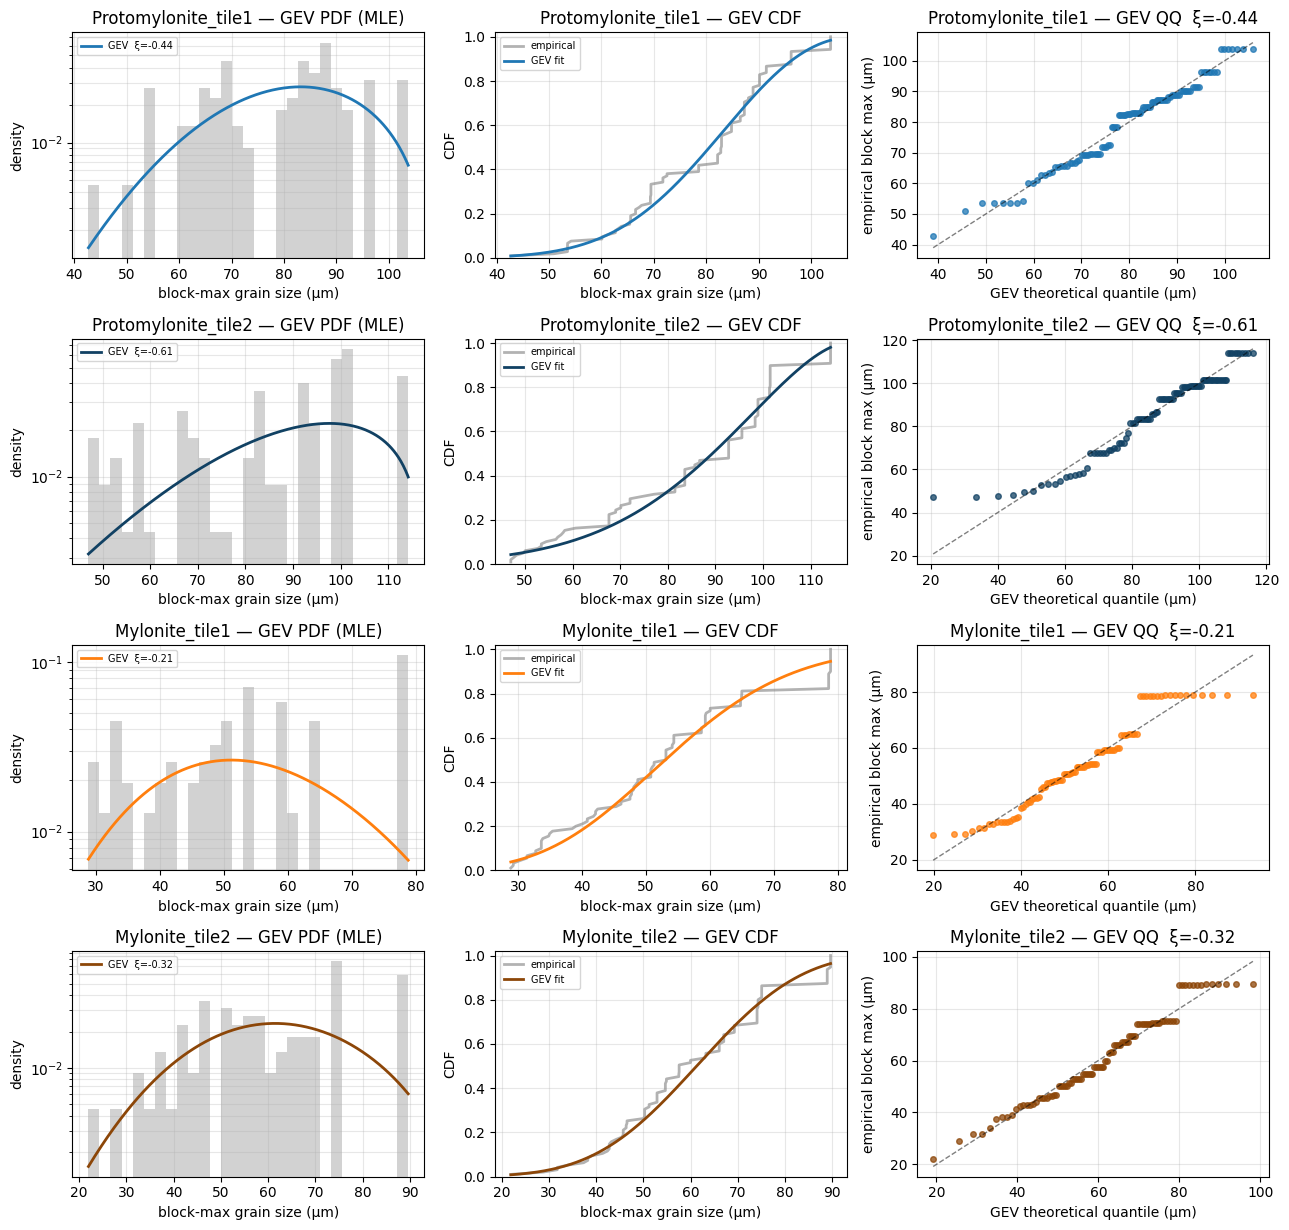

In [139]:
# ──────────────────────────────────────────────────────────────────────
# GEV block-maxima fit — alternative to the GPD peaks-over-threshold
# approach in the previous cell. For i.i.d. exceedances the GEV shape ξ
# of the block-max distribution equals the GPD shape ξ of the tail, so
# getting the two fits to agree is a useful sanity check.
#
# Convention warning (important):
#   scipy.stats.genextreme.c = -ξ in the Coles (2001) / EV-textbook sense
#     scipy.c < 0  →  ξ > 0  →  Fréchet (heavy tail)
#     scipy.c = 0  →  ξ = 0  →  Gumbel
#     scipy.c > 0  →  ξ < 0  →  Weibull (bounded)
# We report ξ = -scipy.c so it matches the GPD ξ from the prev. cell.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

# Physical block size (µm). Rule of thumb: a few times the median grain
# size. Smaller = more blocks (better MLE) but less "independent"; larger
# = fewer blocks but each block more likely to contain a full grain.
BLOCK_UM = 50.0


def block_maxima_spatial(grain_id, block_size_px):
    # Max grain size (in pixels) found inside each non-overlapping square
    # block of side block_size_px. Skips blocks with no indexed grains.
    sizes = np.bincount(grain_id.ravel())
    ny, nx = grain_id.shape
    maxima = []
    for i in range(0, ny - block_size_px + 1, block_size_px):
        for j in range(0, nx - block_size_px + 1, block_size_px):
            b = grain_id[i:i+block_size_px, j:j+block_size_px]
            gids = np.unique(b)
            gids = gids[gids > 0]
            if len(gids) == 0:
                continue
            maxima.append(max(sizes[g] for g in gids))
    return np.array(maxima)


# Fit per sample
gev_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    block_px = max(5, int(round(BLOCK_UM / step)))
    max_px = block_maxima_spatial(d['grain_id'], block_px)
    if len(max_px) < 10:
        print(f'{name}: only {len(max_px)} blocks — skipped')
        continue
    ecd = 2.0 * np.sqrt(max_px / np.pi) * step          # ECD in µm
    try:
        c_sp, loc_gev, scale_gev = stats.genextreme.fit(ecd)
        xi = -c_sp                                        # Coles ξ
    except Exception:
        c_sp = loc_gev = scale_gev = xi = np.nan
    gev_fits[name] = {'maxima': ecd, 'n_blocks': len(ecd), 'block_px': block_px,
                      'c_scipy': c_sp, 'xi': xi,
                      'loc': loc_gev, 'scale': scale_gev}


# Summary: GEV ξ (block maxima) alongside the GPD ξ (POT) from the prev cell
print(f"{'sample':<22s} {'# blocks':>9s} {'block µm':>9s} "
      f"{'GEV ξ':>8s} {'GEV loc':>9s} {'GEV scale':>10s} "
      f"{'GPD ξ':>8s}  {'regime':>10s}")
for name, g in gev_fits.items():
    gpd_xi = fits[name]['xi'] if 'fits' in dir() and name in fits else float('nan')
    r = 'Fréchet' if g['xi'] > 0.05 else ('Weibull' if g['xi'] < -0.05 else 'Gumbel')
    print(f"{name:<22s} {g['n_blocks']:>9d} "
          f"{g['block_px'] * samples[name]['ebsd']['meta']['xstep']:>9.1f} "
          f"{g['xi']:>+8.3f} {g['loc']:>9.2f} {g['scale']:>10.2f} "
          f"{gpd_xi:>+8.3f}  {r:>10s}")


# Standard PDF / CDF / QQ diagnostics for the GEV fits
n = len(gev_fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, g) in enumerate(gev_fits.items()):
    col, _ = sample_style(name)
    x = g['maxima']
    c_sp, loc_gev, scale_gev, xi = g['c_scipy'], g['loc'], g['scale'], g['xi']

    # PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 30)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(x.min(), x.max(), 400)
    ax.plot(xr, stats.genextreme.pdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label=f'GEV  ξ={xi:+.2f}')
    ax.set(xlabel='block-max grain size (µm)', ylabel='density',
           title=f'{name} — GEV PDF (MLE)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # CDF
    ax = axs[row, 1]
    xs = np.sort(x)
    emp = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, emp, '-', color='gray', lw=2, alpha=0.6, label='empirical')
    ax.plot(xr, stats.genextreme.cdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label='GEV fit')
    ax.set(xlabel='block-max grain size (µm)', ylabel='CDF',
           title=f'{name} — GEV CDF')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # QQ
    ax = axs[row, 2]
    n_b = len(xs)
    q_th = stats.genextreme.ppf((np.arange(1, n_b + 1) - 0.5) / n_b,
                                  c_sp, loc=loc_gev, scale=scale_gev)
    ax.plot(q_th, xs, 'o', color=col, ms=4, alpha=0.75)
    mn = min(q_th.min(), xs.min()); mx = max(q_th.max(), xs.max())
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GEV theoretical quantile (µm)',
           ylabel='empirical block max (µm)',
           title=f'{name} — GEV QQ  ξ={xi:+.2f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

sample                  n tail   u (µm)    GEV ξ    GEV μ    GEV σ    GPD ξ      regime
Protomylonite_tile1         31    58.21   -0.063    70.17    10.28   -0.359     Weibull
Protomylonite_tile2         41    47.24   +0.671    55.25     8.88   -0.135     Fréchet
Mylonite_tile1              50    35.69   +0.470    41.03     5.61   -0.126     Fréchet
Mylonite_tile2              50    36.02   +0.323    44.25     7.55   +0.004     Fréchet
Ultramylonite               36     5.47   +0.499     5.99     0.55   -0.107     Fréchet


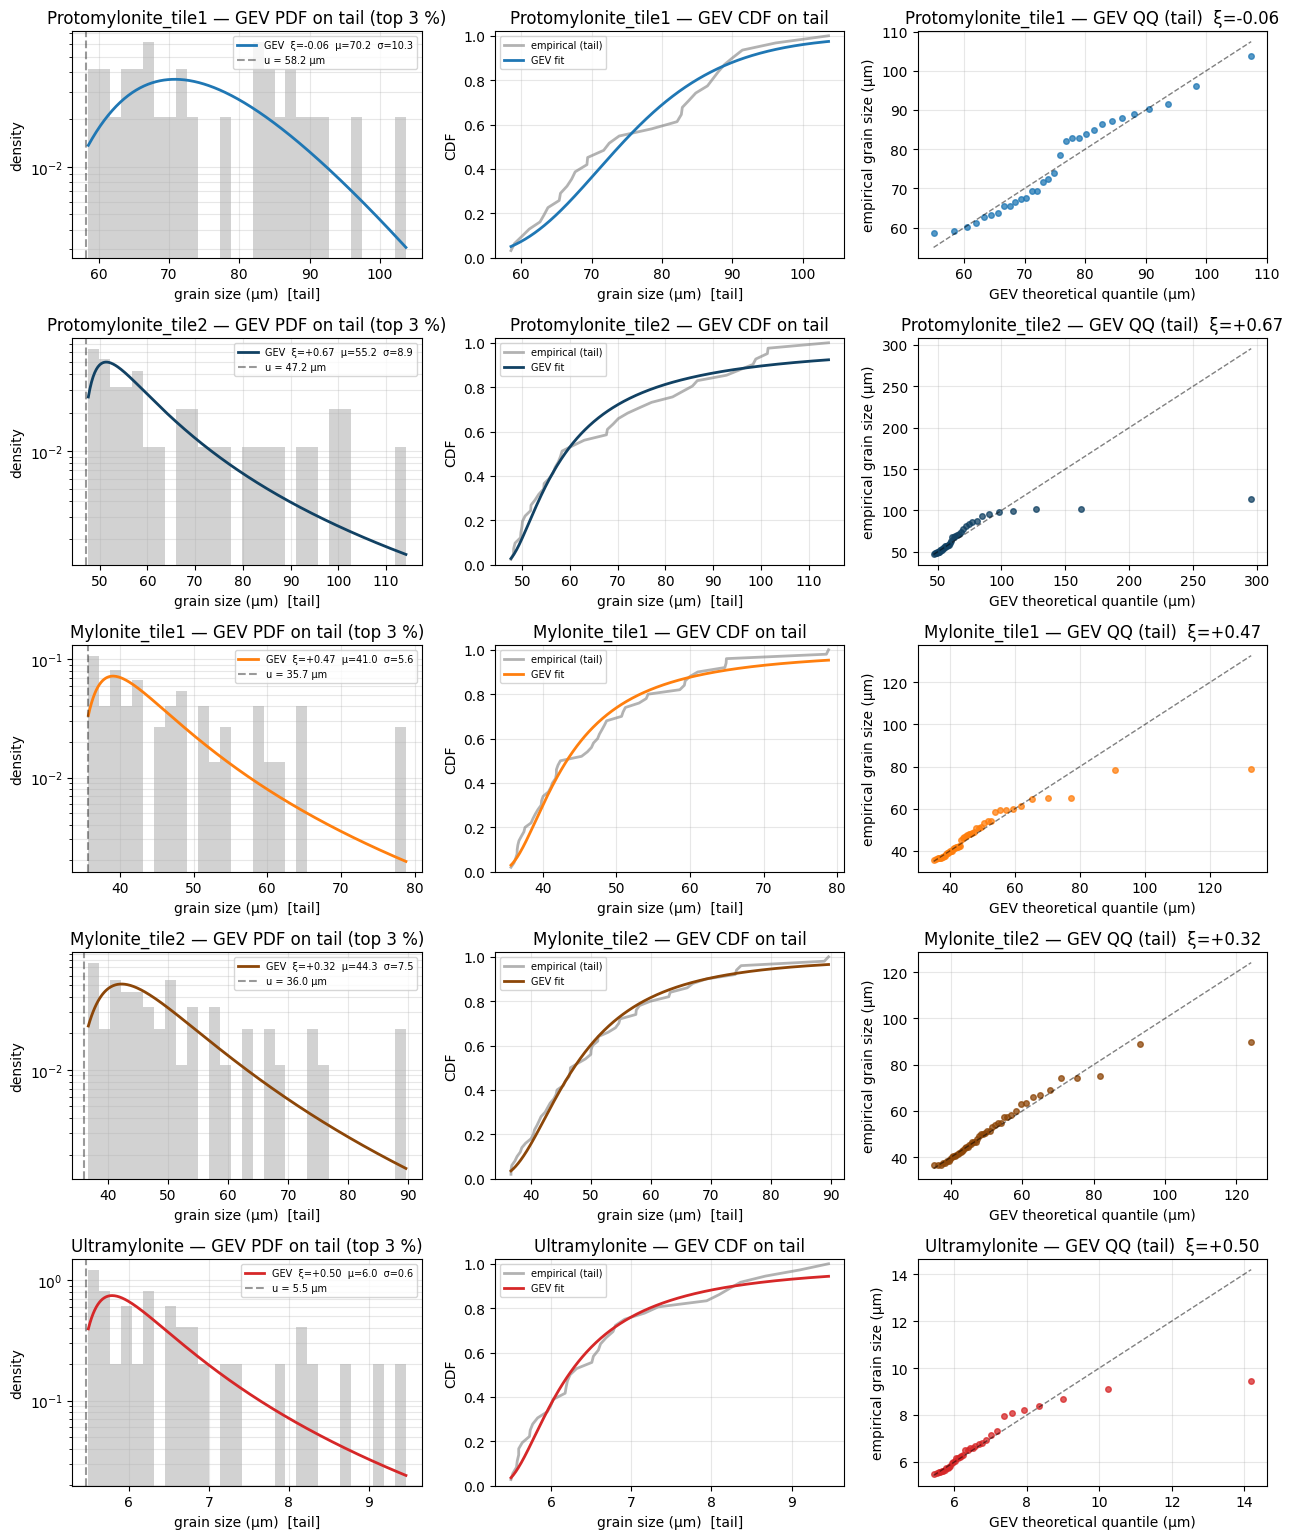

In [145]:
# ──────────────────────────────────────────────────────────────────────
# GEV fit to the TAIL of the grain-size distribution (Hobbs framing:
# GEV describes the extremes, GG describes the bulk).
#
# Methodology: pick a tail threshold u (same quantile as the GPD POT fit
# in the previous cell so they're directly comparable), subset to
# x > u, MLE a GEV on that tail sample.
#
# Convention: ξ = -scipy.c  →  ξ > 0 Fréchet, ξ = 0 Gumbel, ξ < 0 Weibull.
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

TAIL_QUANTILE = 0.97    # top 10 % = "the tail"

gev_tail_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step
    x = ecd[ecd > np.percentile(ecd, 2)]     # drop single-pixel indexing noise
    u = float(np.quantile(x, TAIL_QUANTILE))
    tail = x[x > u]
    if len(tail) < 20:
        print(f'{name}: only {len(tail)} tail points, skipped')
        continue
    try:
        c_sp, loc_gev, scale_gev = stats.genextreme.fit(tail)
        xi = -c_sp
    except Exception:
        c_sp = loc_gev = scale_gev = xi = np.nan
    gev_tail_fits[name] = {'tail': tail, 'u': u, 'n_tail': len(tail),
                            'c_scipy': c_sp, 'xi': xi,
                            'loc': loc_gev, 'scale': scale_gev}


# Summary — GEV ξ on the tail, next to the GPD ξ from the POT cell
print(f"{'sample':<22s} {'n tail':>7s} {'u (µm)':>8s} "
      f"{'GEV ξ':>8s} {'GEV μ':>8s} {'GEV σ':>8s} "
      f"{'GPD ξ':>8s}  {'regime':>10s}")
for name, g in gev_tail_fits.items():
    gpd_xi = fits[name]['xi'] if 'fits' in dir() and name in fits else float('nan')
    r = 'Fréchet' if g['xi'] > 0.05 else ('Weibull' if g['xi'] < -0.05 else 'Gumbel')
    print(f"{name:<22s} {g['n_tail']:>7d} {g['u']:>8.2f} "
          f"{g['xi']:>+8.3f} {g['loc']:>8.2f} {g['scale']:>8.2f} "
          f"{gpd_xi:>+8.3f}  {r:>10s}")


# PDF / CDF / QQ diagnostics on the tail sample
n = len(gev_tail_fits)
fig, axs = plt.subplots(n, 3, figsize=(13, 3.1 * n), squeeze=False)
for row, (name, g) in enumerate(gev_tail_fits.items()):
    col, _ = sample_style(name)
    x = g['tail']
    c_sp, loc_gev, scale_gev, xi = g['c_scipy'], g['loc'], g['scale'], g['xi']

    # PDF
    ax = axs[row, 0]
    bins = np.linspace(x.min(), x.max(), 30)
    ax.hist(x, bins=bins, density=True, alpha=0.35, color='gray', edgecolor='none')
    xr = np.linspace(x.min(), x.max(), 400)
    ax.plot(xr, stats.genextreme.pdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2,
            label=f'GEV  ξ={xi:+.2f}  μ={loc_gev:.1f}  σ={scale_gev:.1f}')
    ax.axvline(g['u'], ls='--', color='k', alpha=0.4, label=f'u = {g["u"]:.1f} µm')
    ax.set(xlabel='grain size (µm)  [tail]', ylabel='density',
           title=f'{name} — GEV PDF on tail (top {int(100*(1-TAIL_QUANTILE))} %)')
    ax.set_yscale('log')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # CDF
    ax = axs[row, 1]
    xs = np.sort(x)
    emp = np.arange(1, len(xs) + 1) / len(xs)
    ax.plot(xs, emp, '-', color='gray', lw=2, alpha=0.6, label='empirical (tail)')
    ax.plot(xr, stats.genextreme.cdf(xr, c_sp, loc=loc_gev, scale=scale_gev),
            '-', color=col, lw=2, label='GEV fit')
    ax.set(xlabel='grain size (µm)  [tail]', ylabel='CDF',
           title=f'{name} — GEV CDF on tail')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.02)

    # QQ
    ax = axs[row, 2]
    n_b = len(xs)
    q_th = stats.genextreme.ppf((np.arange(1, n_b + 1) - 0.5) / n_b,
                                  c_sp, loc=loc_gev, scale=scale_gev)
    ax.plot(q_th, xs, 'o', color=col, ms=4, alpha=0.75)
    mn = min(q_th.min(), xs.min()); mx = max(q_th.max(), xs.max())
    ax.plot([mn, mx], [mn, mx], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='GEV theoretical quantile (µm)',
           ylabel='empirical grain size (µm)',
           title=f'{name} — GEV QQ (tail)  ξ={xi:+.2f}')
    ax.grid(True, alpha=0.3)

fig.tight_layout()

/Users/amasaryk/miniforge/envs/xsmurf/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:1325: RuntimeWarning: overflow encountered in power
  return np.log(c) + np.log(d) + sc.xlogy(c - 1, x) + sc.xlog1py(-d-1, x**c)


sample                  top-3 fits (AIC lower = better)                             
Protomylonite_tile1     GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+6001.3), Pareto IV (ΔAIC=+6072.5)
Protomylonite_tile2     GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+11254.8), Pareto IV (ΔAIC=+11368.4)
Mylonite_tile1          GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+7914.4), Pareto IV (ΔAIC=+8007.8)
Mylonite_tile2          GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+7626.8), Pareto IV (ΔAIC=+7725.9)
Ultramylonite           GEV (ΔAIC=+0.0), Pareto I (ΔAIC=+5302.9), Pareto IV (ΔAIC=+5360.7)


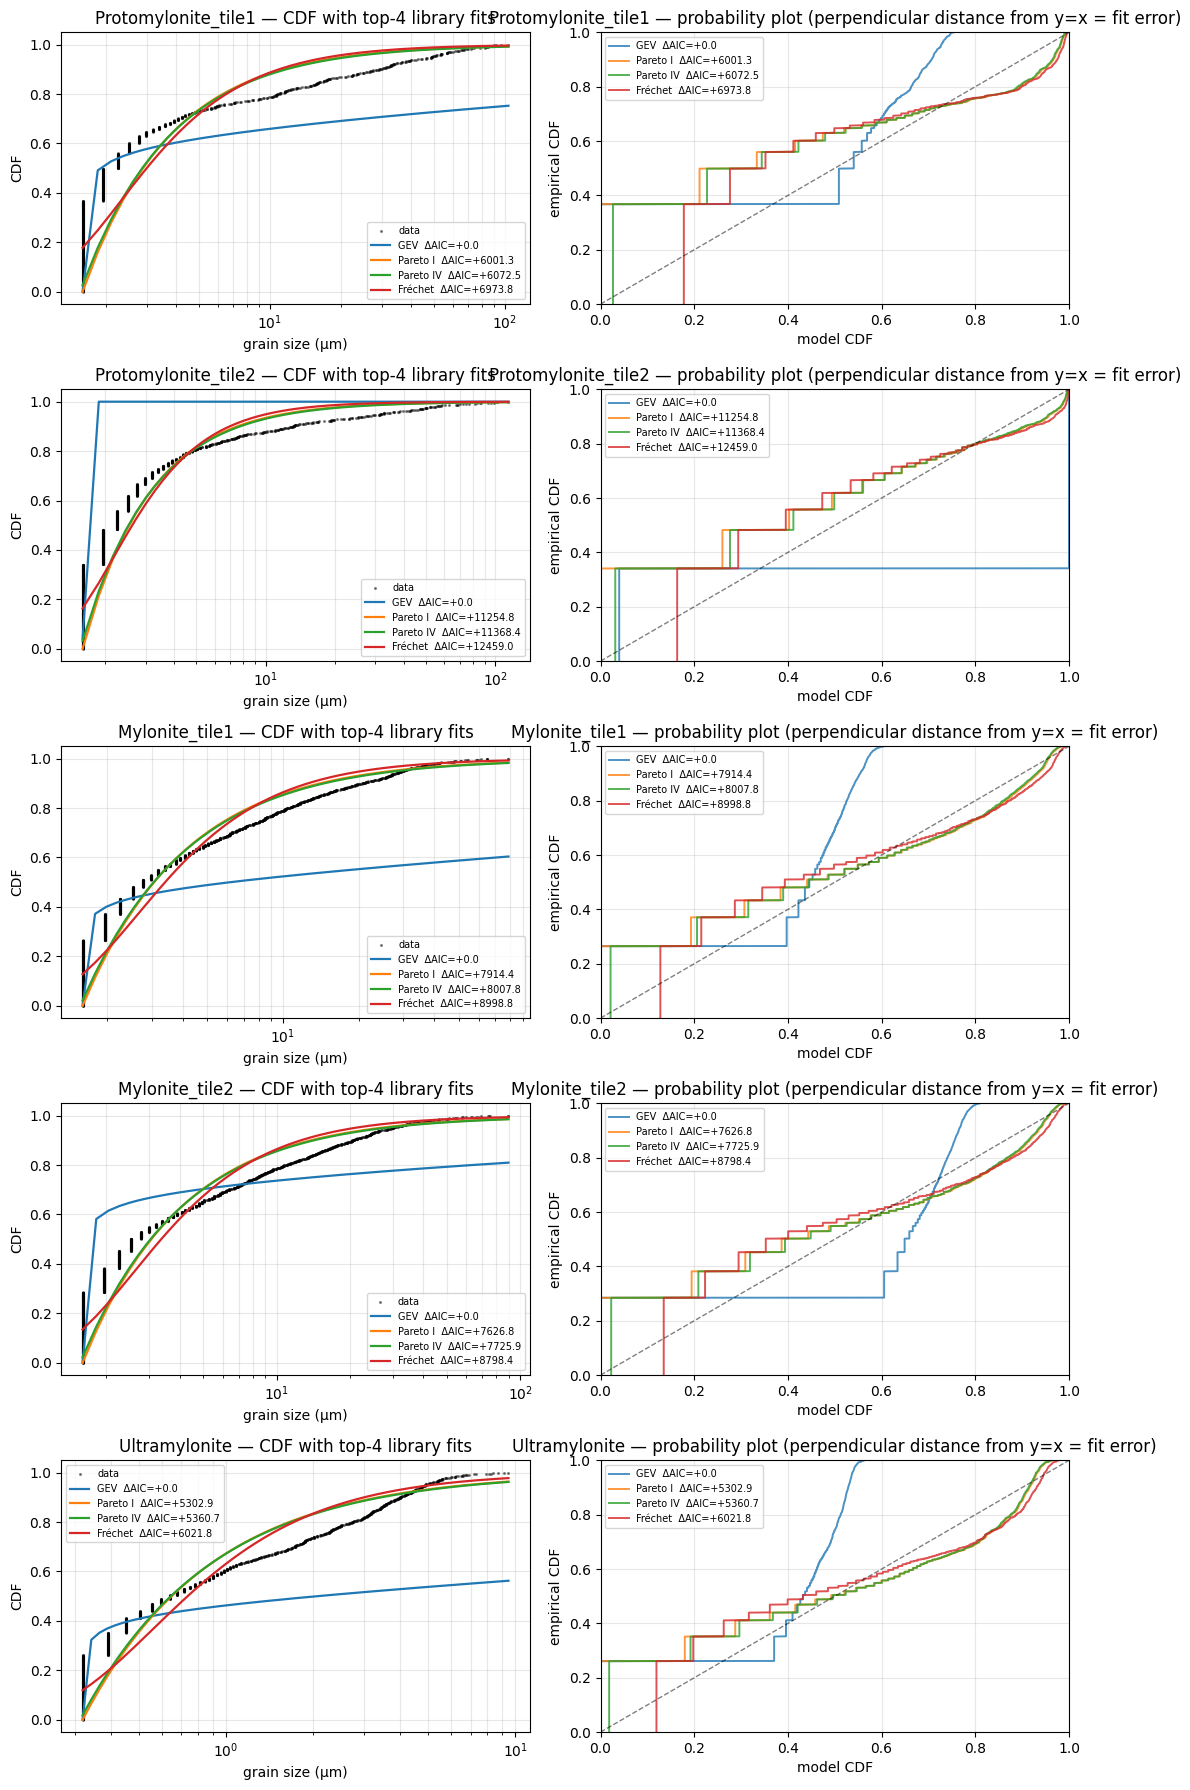

In [154]:
# ──────────────────────────────────────────────────────────────────────
# Ord, Blenkinsop & Hobbs (2022) methodology — fit a LIBRARY of
# candidate distributions to each grain-size sample, rank by AIC, pick
# the winning family per sample. Report the top three fits with the
# standard PDF + probability-plot (Q-Q) diagnostics they show in Fig 6.
#
# Library (scipy equivalents of the Ord et al. Table 2 list):
#   Fréchet        — stats.invweibull        Weibull        — stats.weibull_min
#   Exponential    — stats.expon             Gamma          — stats.gamma
#   Gen. Gamma     — stats.gengamma          Gumbel         — stats.gumbel_r
#   Log-normal     — stats.lognorm           Pareto I       — stats.pareto
#   Pareto II/Lomax— stats.lomax             Pareto IV/Burr — stats.burr12
#   GEV            — stats.genextreme        Gen. Pareto    — stats.genpareto
# ──────────────────────────────────────────────────────────────────────
from scipy import stats

LIBRARY = {
    'Fréchet':     (stats.invweibull,  {'floc': 0}),
    'Weibull':     (stats.weibull_min, {'floc': 0}),
    'Exponential': (stats.expon,       {'floc': 0}),
    'Gamma':       (stats.gamma,       {'floc': 0}),
    'GenGamma':    (stats.gengamma,    {'floc': 0}),
    'Gumbel':      (stats.gumbel_r,    {}),
    'LogNormal':   (stats.lognorm,     {'floc': 0}),
    'Pareto I':    (stats.pareto,      {'floc': 0}),
    'Pareto II':   (stats.lomax,       {'floc': 0}),
    'Pareto IV':   (stats.burr12,      {'floc': 0}),
    'GEV':         (stats.genextreme,  {}),
    'GenPareto':   (stats.genpareto,   {'floc': 0}),
}

def rank_library(x):
    results = {}
    for name, (dist, kwargs) in LIBRARY.items():
        try:
            params = dist.fit(x, **kwargs)
            ll = dist.logpdf(x, *params).sum()
            k  = len(params) - sum(1 for kw in kwargs if kw.startswith('f'))
            if not np.isfinite(ll):
                continue
            aic = 2 * k - 2 * ll
            results[name] = {'dist': dist, 'params': params,
                             'll': float(ll), 'k': int(k), 'aic': float(aic)}
        except Exception:
            continue
    return results


# Fit + rank per sample
library_fits = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    sizes_px = np.bincount(d['grain_id'].ravel())[1:]
    sizes_px = sizes_px[sizes_px > 0]
    ecd = 2.0 * np.sqrt(sizes_px / np.pi) * step
    x = ecd[ecd > np.percentile(ecd, 2)]
    results = rank_library(x)
    # Sort by AIC (lowest = best)
    ranked = sorted(results.items(), key=lambda kv: kv[1]['aic'])
    library_fits[name] = {'x': x, 'ranked': ranked}


# Report: per sample, top 3 fits
print(f"{'sample':<22s}  {'top-3 fits (AIC lower = better)':<60s}")
for name, f in library_fits.items():
    top3 = ', '.join(f"{nm} (ΔAIC={info['aic']-f['ranked'][0][1]['aic']:+.1f})"
                      for nm, info in f['ranked'][:3])
    print(f"{name:<22s}  {top3}")


# Per-sample diagnostic: probability plot (Q-Q) with the top 4 candidates
# overlaid, exactly like Ord et al. Fig 6(b). Points on the diagonal =
# good fit; systematic departure = poor fit.
n = len(library_fits)
fig, axs = plt.subplots(n, 2, figsize=(11, 3.6 * n), squeeze=False)
for row, (name, f) in enumerate(library_fits.items()):
    x = f['x']
    xs = np.sort(x)
    emp = (np.arange(1, len(xs) + 1) - 0.5) / len(xs)     # empirical CDF
    top4 = f['ranked'][:4]

    # -- (left) raw CDF with top-4 overlaid (like Ord Fig 6a)
    ax = axs[row, 0]
    ax.plot(xs, emp, 'k.', ms=2.5, alpha=0.4, label='data')
    xr = np.linspace(xs.min(), xs.max(), 400)
    for rk, (nm, info) in enumerate(top4):
        ax.plot(xr, info['dist'].cdf(xr, *info['params']),
                lw=1.6, label=f"{nm}  ΔAIC={info['aic']-top4[0][1]['aic']:+.1f}")
    ax.set(xlabel='grain size (µm)', ylabel='CDF',
           title=f'{name} — CDF with top-4 library fits')
    ax.set_xscale('log'); ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.3)

    # -- (right) probability plot (Q-Q) — Ord Fig 6b style
    ax = axs[row, 1]
    for rk, (nm, info) in enumerate(top4):
        # "probability axis": empirical CDF vs model CDF at each data point
        model_cdf = info['dist'].cdf(xs, *info['params'])
        ax.plot(model_cdf, emp, lw=1.4, alpha=0.8,
                label=f"{nm}  ΔAIC={info['aic']-top4[0][1]['aic']:+.1f}")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, lw=1)
    ax.set(xlabel='model CDF', ylabel='empirical CDF',
           title=f'{name} — probability plot (perpendicular distance from y=x = fit error)',
           xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.tight_layout()

sample                 edge grains  edge px %  ALL top-3                                 INTERIOR top-3                          
Protomylonite_tile1     123/3032 (4%)     26.2%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Protomylonite_tile2     112/3532 (3%)     30.5%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Mylonite_tile1          182/4322 (4%)     14.8%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Mylonite_tile2          255/4421 (6%)     12.7%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                
Ultramylonite            73/2920 (2%)      1.4%  GEV, Pareto I, Pareto IV                  GEV, Pareto I, Pareto IV                


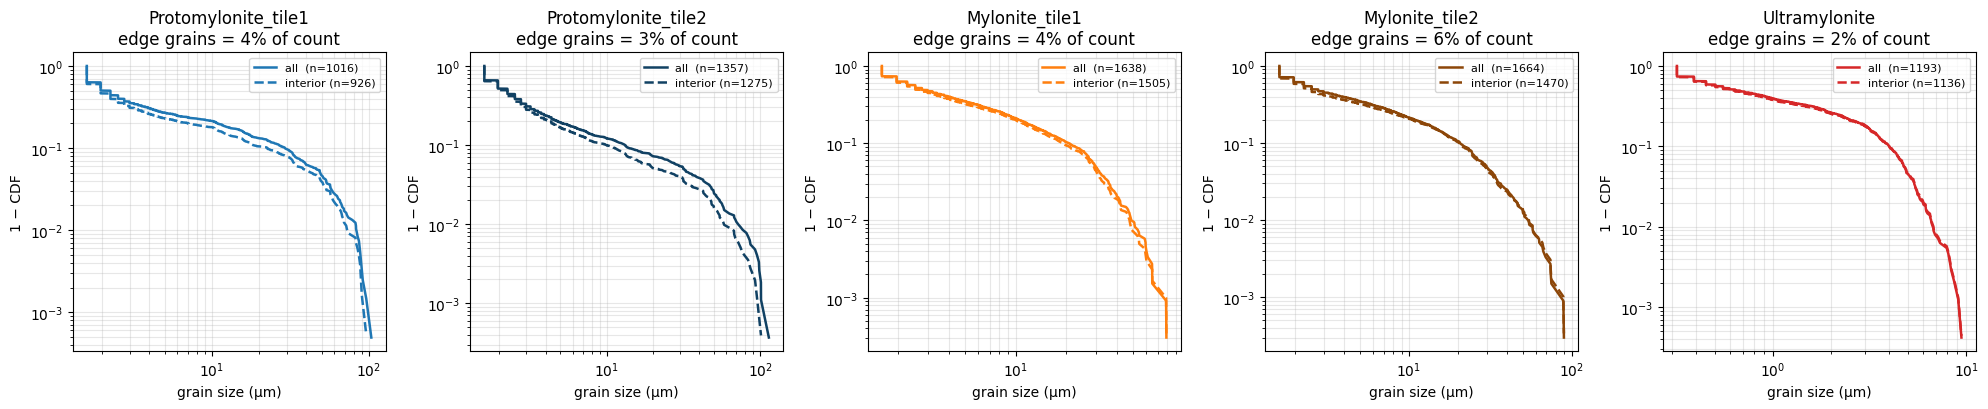

In [155]:
# ──────────────────────────────────────────────────────────────────────
# Edge-grain bias check.
# A grain that touches row 0/row -1/col 0/col -1 is truncated: we report
# its intersection with the map rather than its true size. This biases
# the tail DOWN, because large grains are more likely to touch an edge.
# Compare library rankings on (a) ALL grains vs (b) INTERIOR grains only.
# ──────────────────────────────────────────────────────────────────────

def edge_grain_ids(grain_id):
    edges = np.concatenate([
        grain_id[0, :],   grain_id[-1, :],
        grain_id[:,  0],  grain_id[:,  -1],
    ])
    return np.unique(edges[edges > 0])


# Refit the library on (a) all grains and (b) interior-only
library_fits_cmp = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    gid = d['grain_id']
    sizes = np.bincount(gid.ravel())         # idx 0 = background
    edge_ids = edge_grain_ids(gid)

    # (a) ALL grains (what we've been doing)
    sizes_all = sizes[1:].copy()
    sizes_all = sizes_all[sizes_all > 0]
    ecd_all = 2.0 * np.sqrt(sizes_all / np.pi) * step
    x_all = ecd_all[ecd_all > np.percentile(ecd_all, 2)]

    # (b) INTERIOR only
    interior_ids = np.setdiff1d(np.arange(1, len(sizes)), edge_ids)
    sizes_int = sizes[interior_ids]
    sizes_int = sizes_int[sizes_int > 0]
    ecd_int = 2.0 * np.sqrt(sizes_int / np.pi) * step
    x_int = ecd_int[ecd_int > np.percentile(ecd_int, 2)] if len(ecd_int) > 20 else ecd_int

    library_fits_cmp[name] = {
        'x_all': x_all,        'x_int': x_int,
        'ranked_all': sorted(rank_library(x_all).items(), key=lambda kv: kv[1]['aic']),
        'ranked_int': sorted(rank_library(x_int).items(), key=lambda kv: kv[1]['aic']),
        'n_edge': len(edge_ids),
        'n_total_grains': len(sizes) - 1,
        'edge_pixel_fraction': np.isin(gid, edge_ids).sum() / gid.size,
    }


# Report: what fraction are edge grains, and do the winning families shift?
print(f"{'sample':<22s} {'edge grains':>11s} {'edge px %':>10s}  "
      f"{'ALL top-3':<40s}  {'INTERIOR top-3':<40s}")
for name, f in library_fits_cmp.items():
    frac_grains = f['n_edge'] / max(f['n_total_grains'], 1)
    all3 = ', '.join(nm for nm, _ in f['ranked_all'][:3])
    int3 = ', '.join(nm for nm, _ in f['ranked_int'][:3])
    print(f"{name:<22s} {f['n_edge']:>4d}/{f['n_total_grains']:<4d} "
          f"({100*frac_grains:.0f}%) {100*f['edge_pixel_fraction']:>8.1f}%  "
          f"{all3:<40s}  {int3:<40s}")


# Overlay the CDFs from both versions on a single figure per sample,
# so you can see how much the tail actually shifts
n = len(library_fits_cmp)
fig, axs = plt.subplots(1, n, figsize=(4 * n, 4.2), squeeze=False)
for i, (name, f) in enumerate(library_fits_cmp.items()):
    col, _ = sample_style(name)
    ax = axs[0, i]
    xa = np.sort(f['x_all']);  ca = (np.arange(len(xa)) + 0.5) / len(xa)
    xb = np.sort(f['x_int']);  cb = (np.arange(len(xb)) + 0.5) / len(xb)
    ax.plot(xa, 1 - ca, '-',  color=col, lw=1.8, label=f'all  (n={len(xa)})')
    ax.plot(xb, 1 - cb, '--', color=col, lw=1.8, label=f'interior (n={len(xb)})')
    ax.set(xlabel='grain size (µm)', ylabel='1 − CDF',
           title=f'{name}\nedge grains = {100*f["n_edge"]/max(f["n_total_grains"],1):.0f}% of count')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

Protomylonite_tile1     φ=0.955  best blobiness=1.30  L2 mismatch=6.45e-06  voxel=1.72 µm
Protomylonite_tile2     φ=0.842  best blobiness=1.27  L2 mismatch=1.70e-04  voxel=1.72 µm
Mylonite_tile1          φ=0.886  best blobiness=0.94  L2 mismatch=5.83e-05  voxel=1.20 µm
Mylonite_tile2          φ=0.904  best blobiness=1.02  L2 mismatch=3.54e-05  voxel=1.20 µm
Ultramylonite           φ=0.234  best blobiness=1.65  L2 mismatch=1.15e-03  voxel=0.66 µm


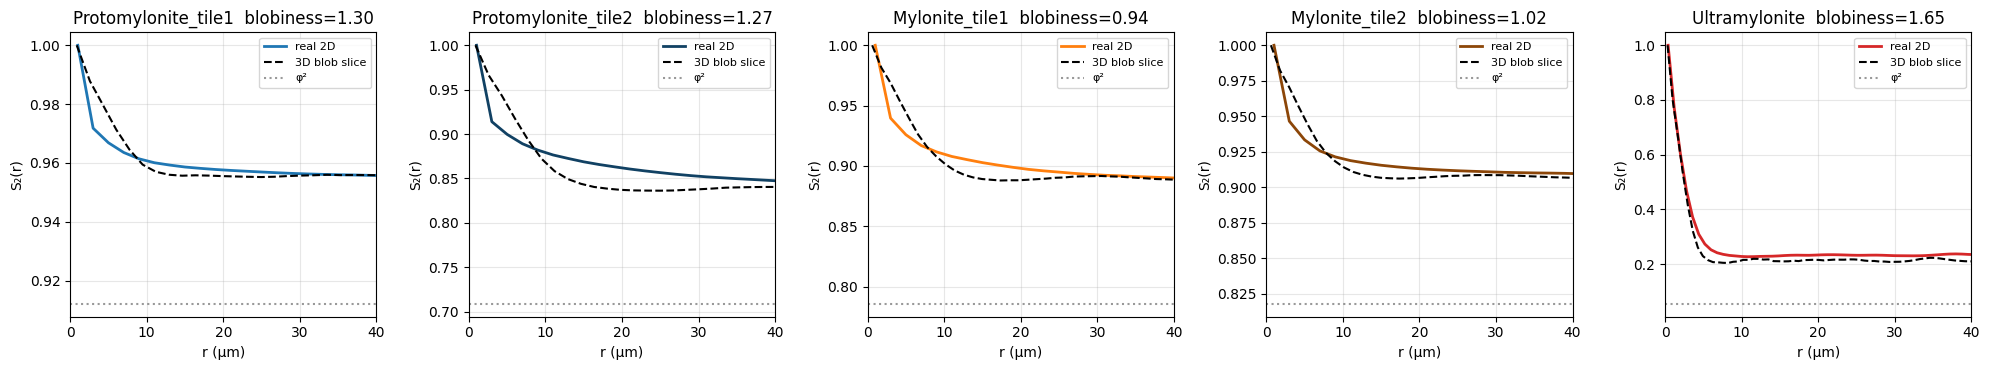

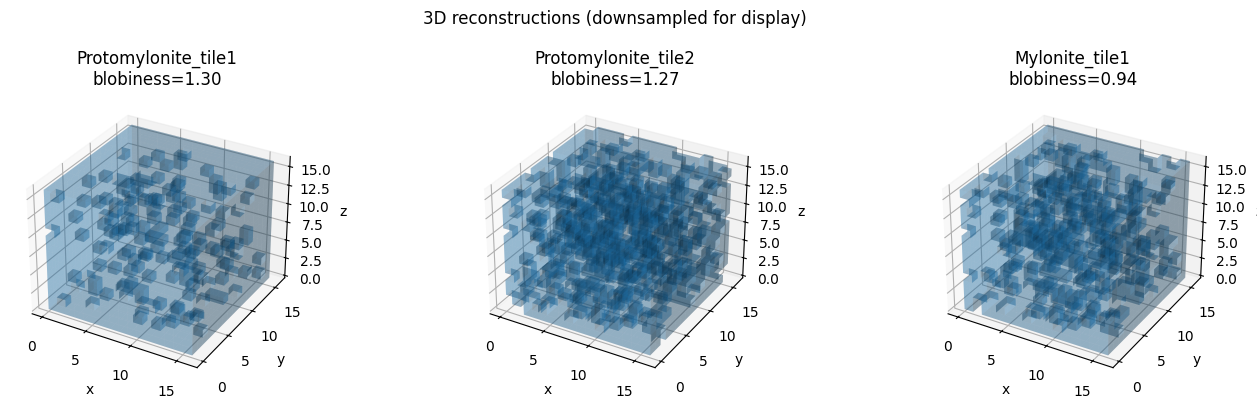

In [156]:
# ──────────────────────────────────────────────────────────────────────
# Forward-match a 3D Gaussian-random-field blobs model to each KMZ sample.
# Target: the measured quartz fraction φ and isotropic S₂(r).
# Generator: porespy.generators.blobs — a thresholded anisotropic noise
# field whose 'blobiness' parameter controls the characteristic feature
# size. Increasing blobiness shrinks features; decreasing it grows them.
# The 2D slice S₂(r) of the 3D volume should match the 2D S₂(r) of the
# original EBSD if the microstructure is reasonably isotropic.
# ──────────────────────────────────────────────────────────────────────
import porespy as ps
from scipy import optimize


def tune_blobiness(target_phi, target_s2, target_r, shape=(128, 128, 128),
                    seed=0):
    def cost(b):
        im = ps.generators.blobs(shape=shape, porosity=target_phi,
                                  blobiness=float(b), seed=seed)
        # Central slice S₂
        s2 = ps.metrics.two_point_correlation(im[shape[0] // 2])
        # Interpolate to target r grid and compute L2 mismatch
        s2_interp = np.interp(target_r, s2.distance, s2.probability,
                               right=target_phi ** 2)
        return np.mean((s2_interp - target_s2) ** 2)
    res = optimize.minimize_scalar(cost, bounds=(0.2, 3.0), method='bounded',
                                    options={'xatol': 0.05})
    return float(res.x), float(res.fun)


recon_3d = {}
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    mask = d['quartz_mask']
    phi  = float(mask.mean())

    # Measured 2D S₂ of the real sample
    s2_2d = ps.metrics.two_point_correlation(mask)
    r_um = s2_2d.distance * step

    # Tune blobiness to match — units: all r in 'pixels' of the synthetic
    # volume. To match physical scales, rescale r_um to synthetic pixels
    # assuming the 128³ volume represents ~max(r_um) µm in each direction.
    max_r_um = np.quantile(r_um, 0.6)                # fit only bulk of S₂
    pix_um = max_r_um / 64                            # synthetic voxel size (µm)
    target_r_px = r_um[r_um < max_r_um] / pix_um
    target_s2   = s2_2d.probability[r_um < max_r_um]

    best_b, resid = tune_blobiness(phi, target_s2, target_r_px)

    # Generate final 3D with the tuned blobiness
    vol = ps.generators.blobs(shape=(128, 128, 128), porosity=phi,
                               blobiness=best_b, seed=0)
    recon_3d[name] = {'blobiness': best_b, 'residual': resid,
                       'pix_um': pix_um, 'volume': vol, 'phi': phi}
    print(f'{name:<22s}  φ={phi:.3f}  best blobiness={best_b:.2f}  '
          f'L2 mismatch={resid:.2e}  voxel={pix_um:.2f} µm')


# Diagnostic: compare real 2D S₂ to 3D slice S₂ for each sample
fig, axs = plt.subplots(1, len(recon_3d), figsize=(4 * len(recon_3d), 3.8),
                         squeeze=False)
for i, (name, r) in enumerate(recon_3d.items()):
    ax = axs[0, i]
    col, _ = sample_style(name)
    # Real S₂
    mask = samples[name]['quartz_mask']
    step = samples[name]['ebsd']['meta']['xstep']
    s2_real = ps.metrics.two_point_correlation(mask)
    ax.plot(s2_real.distance * step, s2_real.probability, '-',
            color=col, lw=2, label='real 2D')
    # 3D slice S₂
    vol = r['volume']
    slice_s2 = ps.metrics.two_point_correlation(vol[vol.shape[0] // 2])
    ax.plot(slice_s2.distance * r['pix_um'], slice_s2.probability, '--',
            color='k', lw=1.5, label='3D blob slice')
    ax.axhline(r['phi'] ** 2, ls=':', color='k', alpha=0.4, label='φ²')
    ax.set(xlabel='r (µm)', ylabel='S₂(r)',
           title=f'{name}  blobiness={r["blobiness"]:.2f}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(0, 40)
fig.tight_layout()


# Quick 3D visualisation of one reconstruction
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(14, 4))
for i, (name, r) in enumerate(list(recon_3d.items())[:3]):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    vol = r['volume']
    # Show a triplet of orthogonal slices
    from skimage import measure
    # Just visualise three mid-planes as textured polygons
    ax.voxels(vol[::8, ::8, ::8], alpha=0.25, edgecolor='none', facecolors='C0')
    ax.set_title(f'{name}\nblobiness={r["blobiness"]:.2f}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
fig.suptitle('3D reconstructions (downsampled for display)')
fig.tight_layout()

Text(0.5, 1.0, 'Long-range correlation check: straight line = power-law = Hobbs-style')

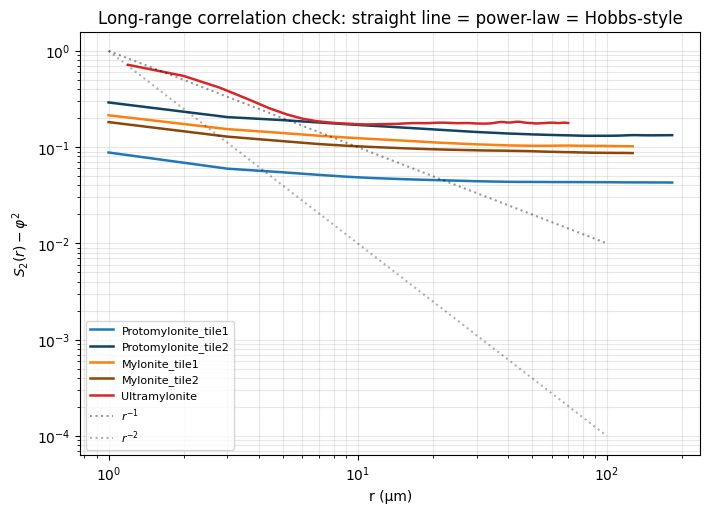

In [157]:
# Is S₂(r) - φ² power-law at large r? Straight line in log-log → yes.
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, d in samples.items():
    step = d['ebsd']['meta']['xstep']
    s2 = ps.metrics.two_point_correlation(d['quartz_mask'])
    r_um = s2.distance * step
    delta = s2.probability - d['phi_quartz'] ** 2
    ok = (delta > 1e-6) & (r_um > 0.5)
    col, _ = sample_style(name)
    ax.loglog(r_um[ok], delta[ok], '-', color=col, lw=1.8, label=name)
    # Reference exponential (short-range) and power-law -1 slope
ax.loglog([1, 100], [1, 1e-2], 'k:', alpha=0.4, label=r'$r^{-1}$')
ax.loglog([1, 100], [1, 1e-4], 'k:', alpha=0.3, label=r'$r^{-2}$')
ax.set(xlabel='r (µm)', ylabel=r'$S_2(r) - \varphi^2$')
ax.legend(fontsize=8); ax.grid(True, which='both', alpha=0.3)
ax.set_title('Long-range correlation check: straight line = power-law = Hobbs-style')